In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
RESULTS_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/"
    "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_scene_split/"
    "step6_pilot_full_ithor120_diverse_qwen2_5_3b_pair_explicit_direct_relation_ld_scene_split_full_results.json"
)

OUT_DIR = OUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_PATH exists:", RESULTS_PATH.exists())
print("Output directory:", OUT_DIR)

RESULTS_PATH exists: True
Output directory: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b


In [ ]:
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

print("Top-level keys:")
print(list(results.keys()))

label_order = results.get("label_order")
if label_order is None:
    sample_layer = results["results_by_layer"][0]
    report = sample_layer["overall"]["classification_report"]
    label_order = [
        k for k in report.keys()
        if k not in ["accuracy", "macro avg", "weighted avg"]
    ]

print("\nLabels:")
print(label_order)

layers_evaluated = results.get("step6_config", {}).get("layer_indices_evaluated", None)
print("\nLayers evaluated:")
print(layers_evaluated)

Top-level keys:
['experiment_id', 'experiment_name', 'description', 'step6_config', 'source_step5_files', 'source_file_summaries', 'merged_record_summary', 'scene_split_info', 'label_order', 'num_layers_total', 'num_layers_evaluated', 'layer_indices_evaluated', 'feature_dim', 'test_subsets', 'best_layer_summary', 'results_by_layer', 'per_layer_label_metrics', 'recall_matrix_long']

Labels:
['above', 'below', 'contains', 'in', 'left_of', 'near', 'on', 'right_of', 'supports']

Layers evaluated:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]


In [ ]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.2
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(filename):
    """
    Save current matplotlib figure as PNG and PDF.
    """
    png_path = OUT_DIR / f"{filename}.png"
    pdf_path = OUT_DIR / f"{filename}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)

In [ ]:
def get_macro_metric(subset_data, metric_name):
    """
    Extract macro avg precision / recall / f1-score from classification_report.
    """
    report = subset_data.get("classification_report", {})
    macro = report.get("macro avg", {})
    return macro.get(metric_name, np.nan)


def get_weighted_metric(subset_data, metric_name):
    """
    Extract weighted avg precision / recall / f1-score from classification_report.
    """
    report = subset_data.get("classification_report", {})
    weighted = report.get("weighted avg", {})
    return weighted.get(metric_name, np.nan)


layer_rows = []

for layer_result in results["results_by_layer"]:
    layer = int(layer_result["layer"])

    for subset in ["train", "overall"]:
        if subset not in layer_result:
            continue

        subset_data = layer_result[subset]

        layer_rows.append({
            "layer": layer,
            "subset": subset,
            "accuracy": subset_data.get("accuracy", np.nan),
            "macro_precision": get_macro_metric(subset_data, "precision"),
            "macro_recall": get_macro_metric(subset_data, "recall"),
            "macro_f1": subset_data.get(
                "macro_f1",
                get_macro_metric(subset_data, "f1-score")
            ),
            "weighted_precision": get_weighted_metric(subset_data, "precision"),
            "weighted_recall": get_weighted_metric(subset_data, "recall"),
            "weighted_f1": get_weighted_metric(subset_data, "f1-score"),
            "n_samples": subset_data.get(
                "num_examples",
                subset_data.get("n_samples", np.nan)
            ),
        })

df_layers = pd.DataFrame(layer_rows)
df_layers = df_layers.sort_values(["subset", "layer"]).reset_index(drop=True)

print(df_layers.head())
print("\nShape:", df_layers.shape)
print("\nSubsets:")
print(df_layers["subset"].value_counts())

   layer   subset  accuracy  macro_precision  macro_recall  macro_f1  \
0      0  overall  0.484848         0.397431      0.550492  0.434862   
1      1  overall  0.832276         0.808553      0.818152  0.811616   
2      2  overall  0.844726         0.812701      0.836339  0.821016   
3      3  overall  0.848250         0.824170      0.837367  0.828642   
4      4  overall  0.837914         0.810127      0.822442  0.814498   

   weighted_precision  weighted_recall  weighted_f1  n_samples  
0            0.458691         0.484848     0.458405       4257  
1            0.837418         0.832276     0.833688       4257  
2            0.850920         0.844726     0.846852       4257  
3            0.854586         0.848250     0.850347       4257  
4            0.843836         0.837914     0.840038       4257  

Shape: (74, 10)

Subsets:
subset
overall    37
train      37
Name: count, dtype: int64


In [ ]:
METRIC_NAME_MAP = {
    "accuracy": "Accuracy",
    "macro_precision": "Macro precision",
    "macro_recall": "Macro recall",
    "macro_f1": "Macro F1",
    "weighted_precision": "Weighted precision",
    "weighted_recall": "Weighted recall",
    "weighted_f1": "Weighted F1",
}


def require_metric_column(df, metric_col):
    """
    Check that metric_col is a real numeric column and has a registered display name.
    """
    if metric_col not in df.columns:
        raise ValueError(
            f"Metric column '{metric_col}' does not exist in dataframe. "
            f"Available columns: {list(df.columns)}"
        )

    if metric_col not in METRIC_NAME_MAP:
        raise ValueError(
            f"Metric column '{metric_col}' exists, but it is not registered in METRIC_NAME_MAP."
        )

    if not pd.api.types.is_numeric_dtype(df[metric_col]):
        raise TypeError(f"Metric column '{metric_col}' is not numeric.")

    if df[metric_col].isna().all():
        raise ValueError(f"Metric column '{metric_col}' contains only NaN values.")

    return METRIC_NAME_MAP[metric_col]


def make_metric_title(prefix, metric_col, suffix, df):
    """
    Build a plot title from a verified real metric column.
    """
    metric_label = require_metric_column(df, metric_col)
    return f"{prefix} {metric_label} {suffix}"


def verify_metric_column(df, metric_col, id_cols=None):
    """
    Print a compact check showing which real column is being plotted.
    """
    metric_label = require_metric_column(df, metric_col)

    if id_cols is None:
        id_cols = ["layer"]

    existing_cols = [col for col in id_cols + [metric_col] if col in df.columns]

    print(f"Verified metric column: {metric_col}")
    print(f"Display label: {metric_label}")
    print(df[existing_cols].head())

    return metric_label

In [ ]:
df_overall = df_layers[df_layers["subset"] == "overall"].copy()
df_overall = df_overall.sort_values("layer").reset_index(drop=True)

df_train_test = df_layers[
    df_layers["subset"].isin(["train", "overall"])
].copy()

df_train_test["split"] = df_train_test["subset"].replace({
    "train": "train",
    "overall": "test"
})

df_train_test = df_train_test.sort_values(["split", "layer"]).reset_index(drop=True)

print("df_overall:")
print(df_overall.head())

print("\ndf_train_test:")
print(df_train_test.head())

print("\ndf_train_test shape:", df_train_test.shape)

df_overall:
   layer   subset  accuracy  macro_precision  macro_recall  macro_f1  \
0      0  overall  0.484848         0.397431      0.550492  0.434862   
1      1  overall  0.832276         0.808553      0.818152  0.811616   
2      2  overall  0.844726         0.812701      0.836339  0.821016   
3      3  overall  0.848250         0.824170      0.837367  0.828642   
4      4  overall  0.837914         0.810127      0.822442  0.814498   

   weighted_precision  weighted_recall  weighted_f1  n_samples  
0            0.458691         0.484848     0.458405       4257  
1            0.837418         0.832276     0.833688       4257  
2            0.850920         0.844726     0.846852       4257  
3            0.854586         0.848250     0.850347       4257  
4            0.843836         0.837914     0.840038       4257  

df_train_test:
   layer   subset  accuracy  macro_precision  macro_recall  macro_f1  \
0      0  overall  0.484848         0.397431      0.550492  0.434862   
1    

In [ ]:
def plot_test_metric_with_best_and_second_worst(metric_col, save_name):
    metric_label = verify_metric_column(df_overall, metric_col, id_cols=["layer"])

    plt.figure(figsize=(18, 6))

    sns.lineplot(
        data=df_overall,
        x="layer",
        y=metric_col,
        marker="o",
        linewidth=2.4,
        palette="muted"
    )

    # Best layer for this metric
    best_row = df_overall.loc[df_overall[metric_col].idxmax()]
    best_metric_layer = int(best_row["layer"])
    best_score = best_row[metric_col]

    # Second worst layer for this metric
    second_worst_row = df_overall.sort_values(
        metric_col,
        ascending=True
    ).iloc[1]

    second_worst_layer = int(second_worst_row["layer"])
    second_worst_score = second_worst_row[metric_col]

    assert np.isclose(best_score, df_overall[metric_col].max()), (
        f"Best score mismatch for {metric_col}"
    )

    assert np.isclose(
        second_worst_score,
        df_overall.sort_values(metric_col, ascending=True).iloc[1][metric_col]
    ), f"Second worst score mismatch for {metric_col}"

    plt.axvline(
        best_metric_layer,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        color="green",
    )

    plt.scatter(
        best_metric_layer,
        best_score,
        s=90,
        color="green",
        zorder=5
    )

    plt.annotate(
        f"Best\nL{best_metric_layer}: {best_score:.3f}",
        xy=(best_metric_layer, best_score),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=11,
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="gray",
            alpha=0.85
        ),
    )

    plt.axvline(
        second_worst_layer,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        color="red",
    )

    plt.scatter(
        second_worst_layer,
        second_worst_score,
        s=90,
        color="red",
        zorder=5
    )

    plt.annotate(
        f"Second worst\nL{second_worst_layer}: {second_worst_score:.3f}",
        xy=(second_worst_layer, second_worst_score),
        xytext=(10, -25),
        textcoords="offset points",
        fontsize=11,
        ha="left",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="gray",
            alpha=0.85
        ),
    )

    plt.title(make_metric_title(
        prefix="Test",
        metric_col=metric_col,
        suffix="across layers",
        df=df_overall
    ))

    plt.xlabel("Layer")
    plt.ylabel(metric_label)
    plt.ylim(0, 1.05)
    plt.yticks(np.arange(0, 1.01, 0.1))
    plt.xticks(sorted(df_overall["layer"].unique()))
    plt.tight_layout()

    save_fig(save_name)
    plt.show()

In [ ]:
BEST_LAYER_METRIC_COL = "macro_f1"
BEST_LAYER_METRIC_LABEL = require_metric_column(df_overall, BEST_LAYER_METRIC_COL)

best_row = df_overall.sort_values(BEST_LAYER_METRIC_COL, ascending=False).iloc[0]
best_layer = int(best_row["layer"])

print(f"Best layer based on overall {BEST_LAYER_METRIC_LABEL}:", best_layer)
print(best_row)

Best layer based on overall Macro F1: 5
layer                        5
subset                 overall
accuracy              0.851304
macro_precision       0.850147
macro_recall           0.84172
macro_f1              0.844544
weighted_precision    0.856376
weighted_recall       0.851304
weighted_f1           0.853008
n_samples                 4257
Name: 5, dtype: object


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_accuracy_precision_recall_f1_with_best_values_in_legend.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_accuracy_precision_recall_f1_with_best_values_in_legend.pdf


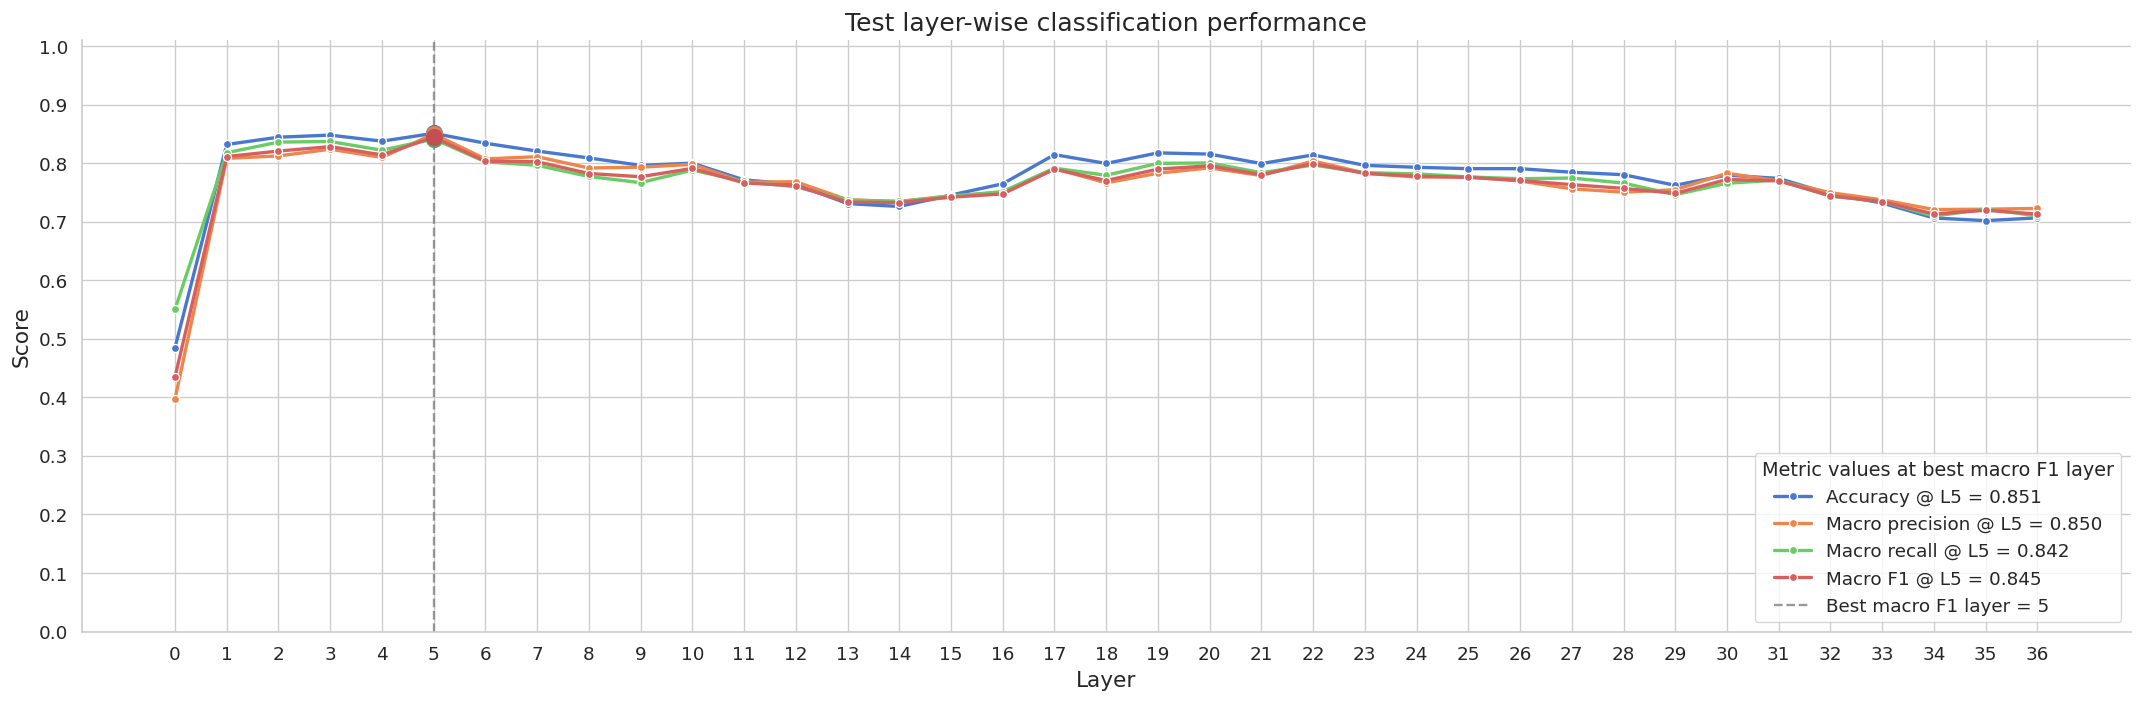

In [ ]:
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]

for metric_col in metric_cols:
    require_metric_column(df_overall, metric_col)

plot_df = df_overall.melt(
    id_vars=["layer"],
    value_vars=metric_cols,
    var_name="metric_col",
    value_name="score"
)

plot_df["metric"] = plot_df["metric_col"].map(METRIC_NAME_MAP)

# 提取全局 best_layer 上各指标数值
best_metrics = df_overall[df_overall["layer"] == best_layer].iloc[0]

best_metric_values = {
    METRIC_NAME_MAP[metric_col]: best_metrics[metric_col]
    for metric_col in metric_cols
}

plot_df["legend_label"] = plot_df["metric"].apply(
    lambda m: f"{m} @ L{best_layer} = {best_metric_values[m]:.3f}"
)

plt.figure(figsize=(18, 6))

sns.lineplot(
    data=plot_df,
    x="layer",
    y="score",
    hue="legend_label",
    marker="o",
    linewidth=2.0,
    palette="muted"
)

plt.axvline(
    best_layer,
    linestyle="--",
    linewidth=1.4,
    alpha=0.8,
    label=f"Best macro F1 layer = {best_layer}",
    color="grey"
)

for metric_name, score in best_metric_values.items():
    plt.scatter(best_layer, score, s=90, zorder=5)

plt.title("Test layer-wise classification performance")
plt.xlabel("Layer")
plt.ylabel("Score")
plt.ylim(0, 1.01)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(sorted(df_overall["layer"].unique()))

plt.legend(
    title="Metric values at best macro F1 layer",
    frameon=True,
    loc="lower right"
)

plt.tight_layout()

save_fig("test_layerwise_accuracy_precision_recall_f1_with_best_values_in_legend")
plt.show()

Verified metric column: accuracy
Display label: Accuracy
   layer  accuracy
0      0  0.484848
1      1  0.832276
2      2  0.844726
3      3  0.848250
4      4  0.837914


/tmp/ipykernel_2789/1777284415.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_accuracy_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_accuracy_with_best_and_second_worst_value.pdf


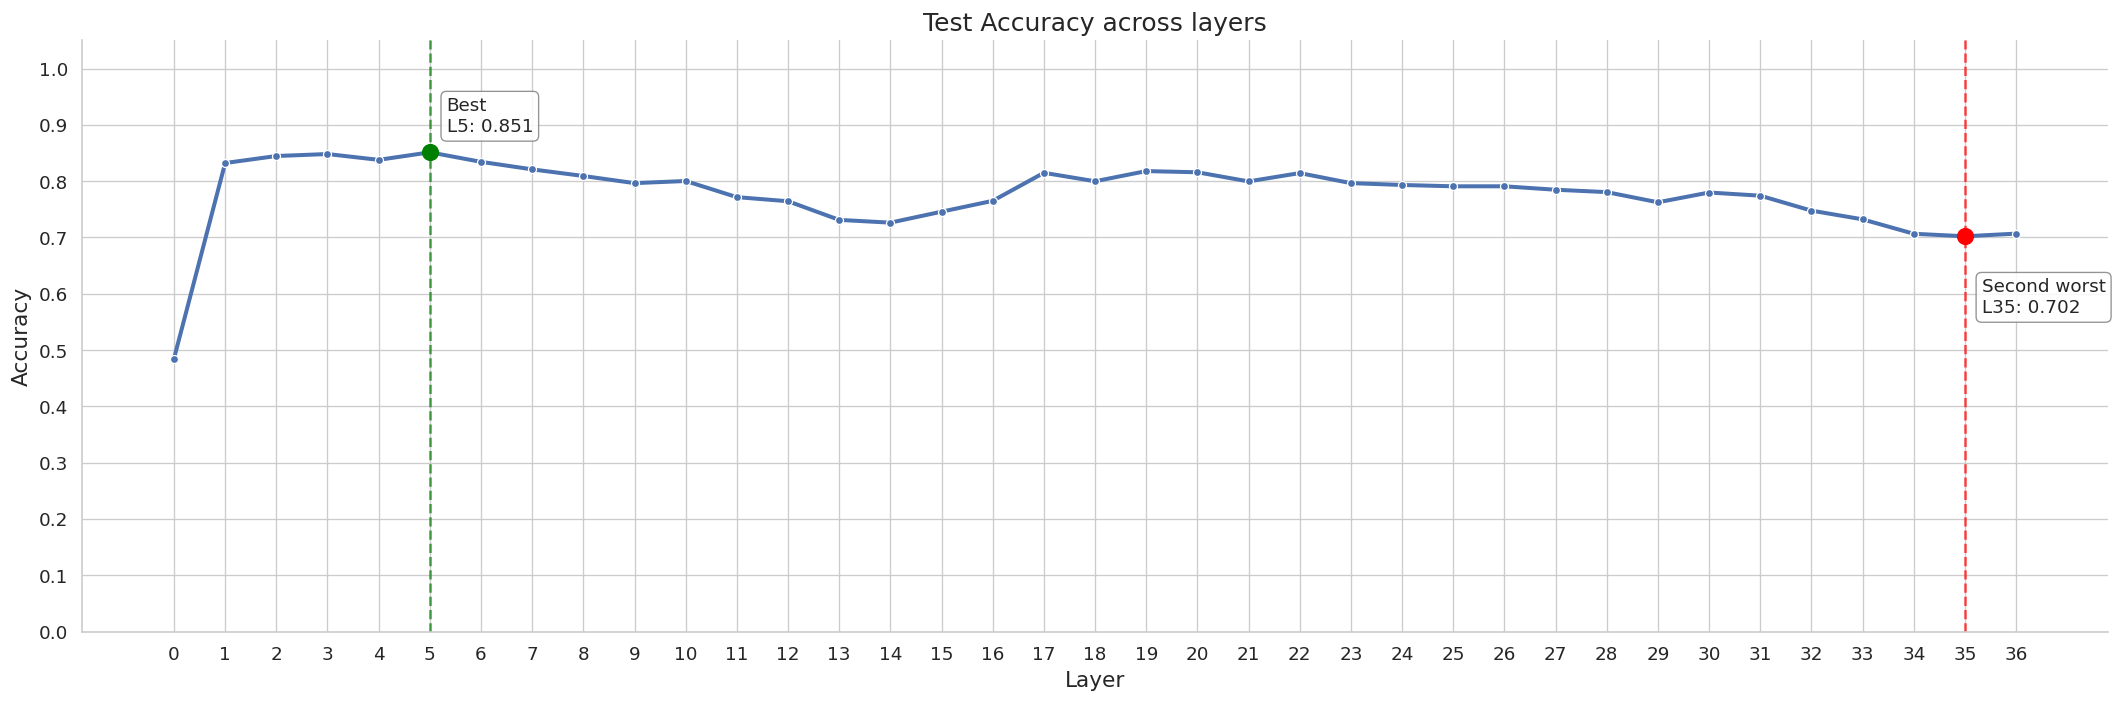

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="accuracy",
    save_name="test_layerwise_accuracy_with_best_and_second_worst_value"
)

Verified metric column: macro_precision
Display label: Macro precision
   layer  macro_precision
0      0         0.397431
1      1         0.808553
2      2         0.812701
3      3         0.824170
4      4         0.810127


/tmp/ipykernel_2789/1777284415.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_precision_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_precision_with_best_and_second_worst_value.pdf


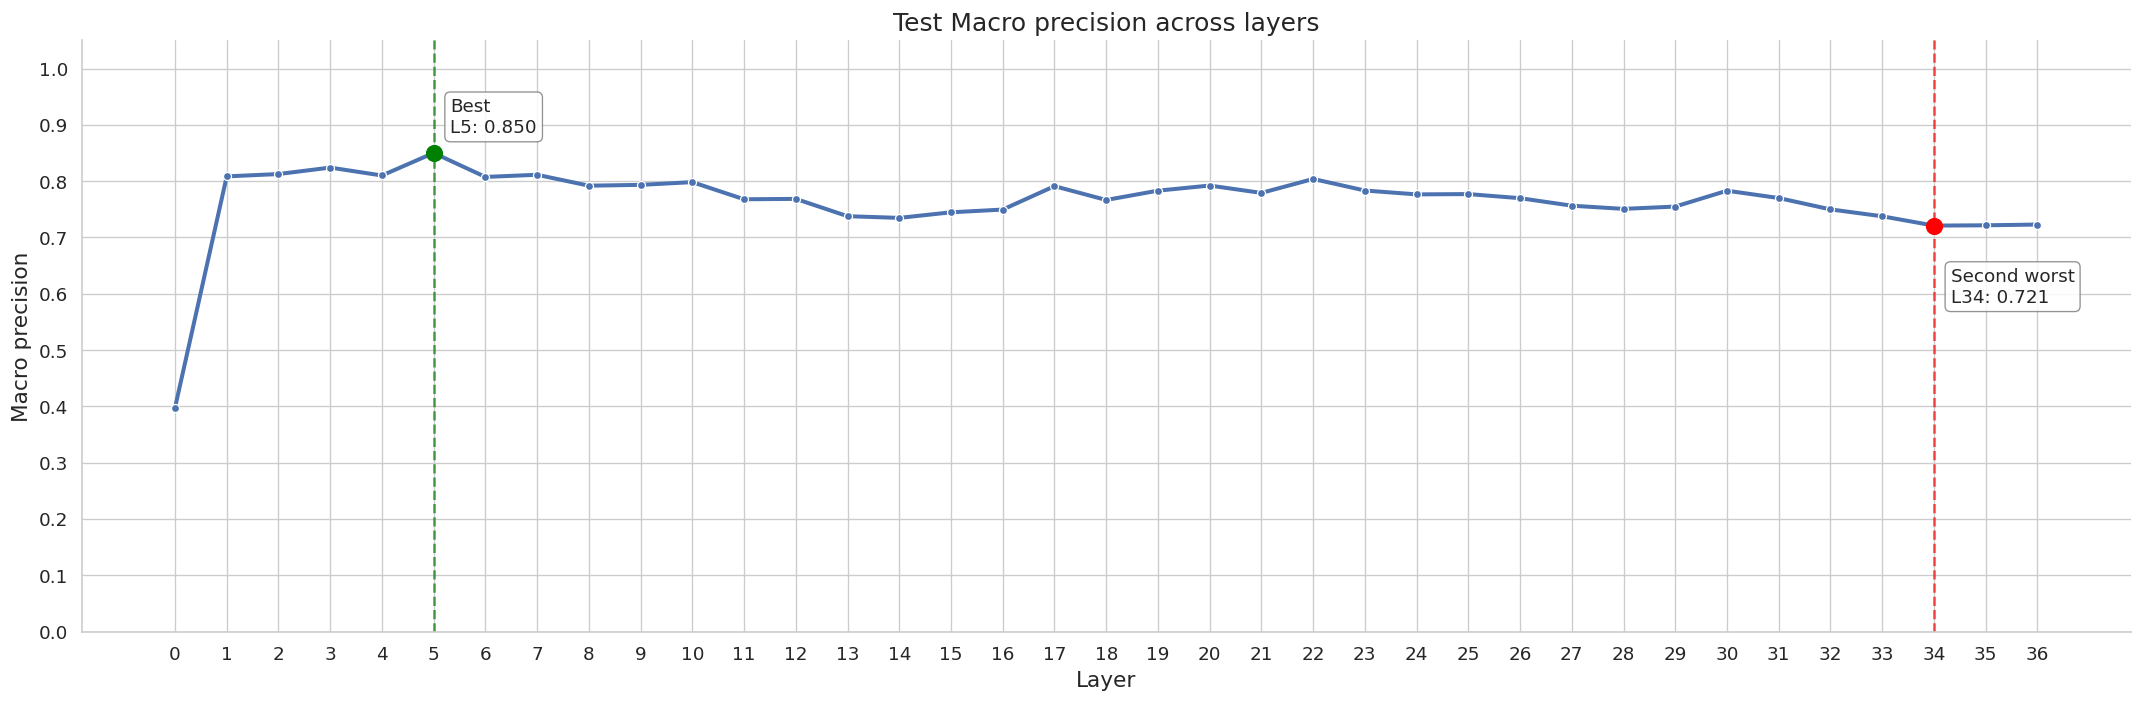

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_precision",
    save_name="test_layerwise_macro_precision_with_best_and_second_worst_value"
)

Verified metric column: macro_recall
Display label: Macro recall
   layer  macro_recall
0      0      0.550492
1      1      0.818152
2      2      0.836339
3      3      0.837367
4      4      0.822442


/tmp/ipykernel_2789/1777284415.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_recall_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_recall_with_best_and_second_worst_value.pdf


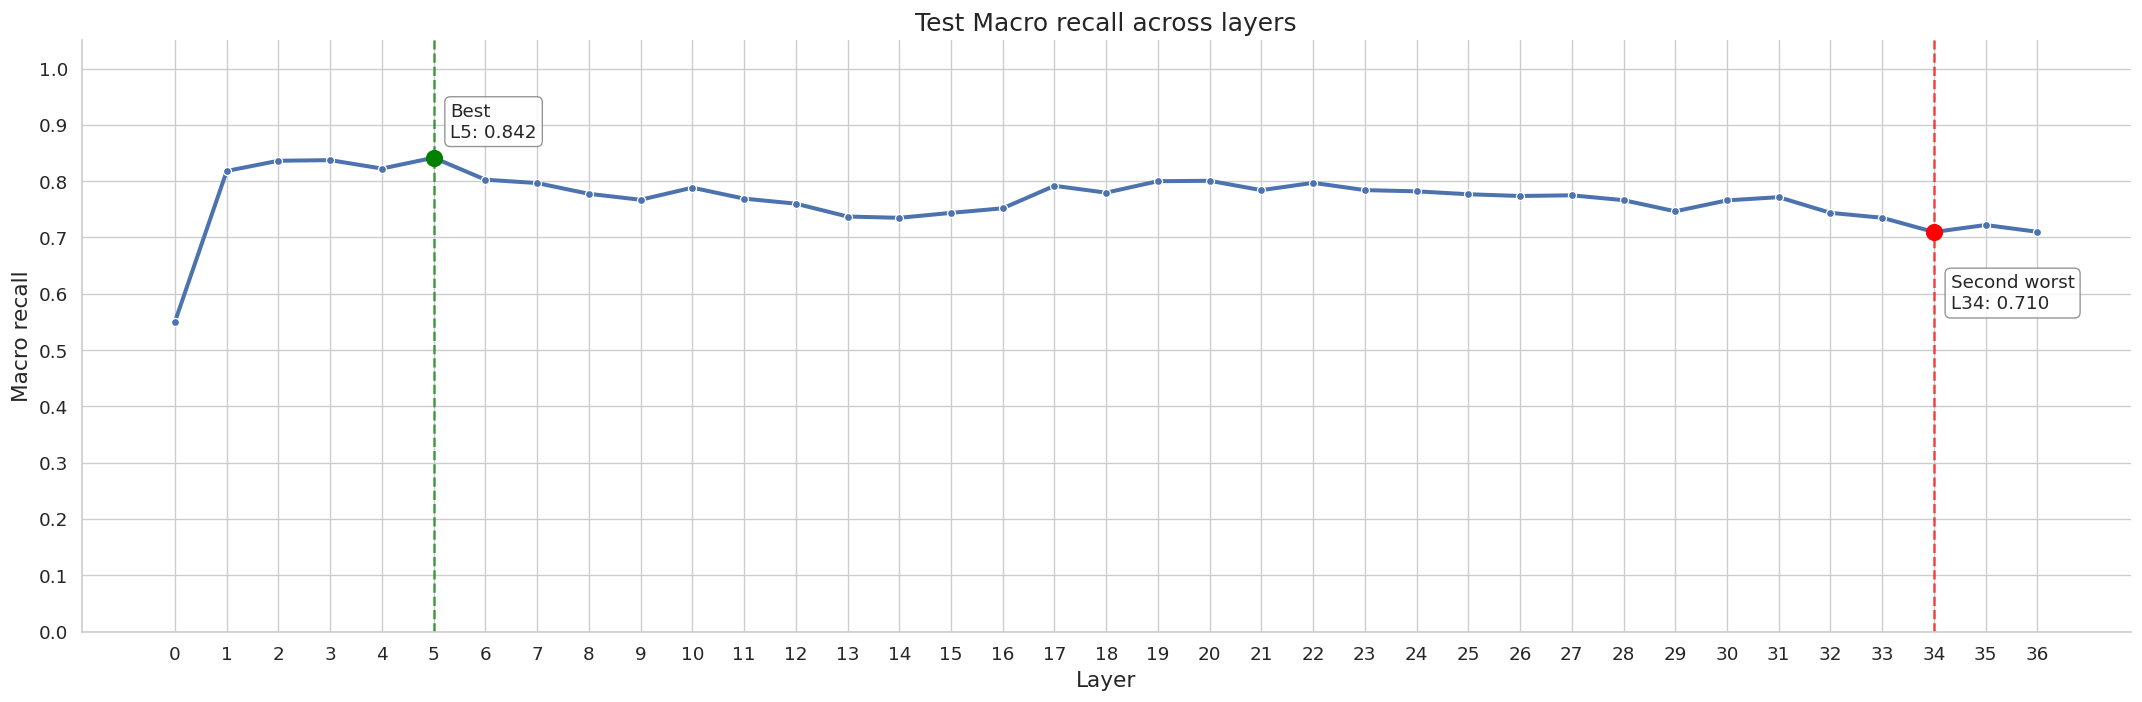

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_recall",
    save_name="test_layerwise_macro_recall_with_best_and_second_worst_value"
)

Verified metric column: macro_f1
Display label: Macro F1
   layer  macro_f1
0      0  0.434862
1      1  0.811616
2      2  0.821016
3      3  0.828642
4      4  0.814498


/tmp/ipykernel_2789/1777284415.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_f1_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/test_layerwise_macro_f1_with_best_and_second_worst_value.pdf


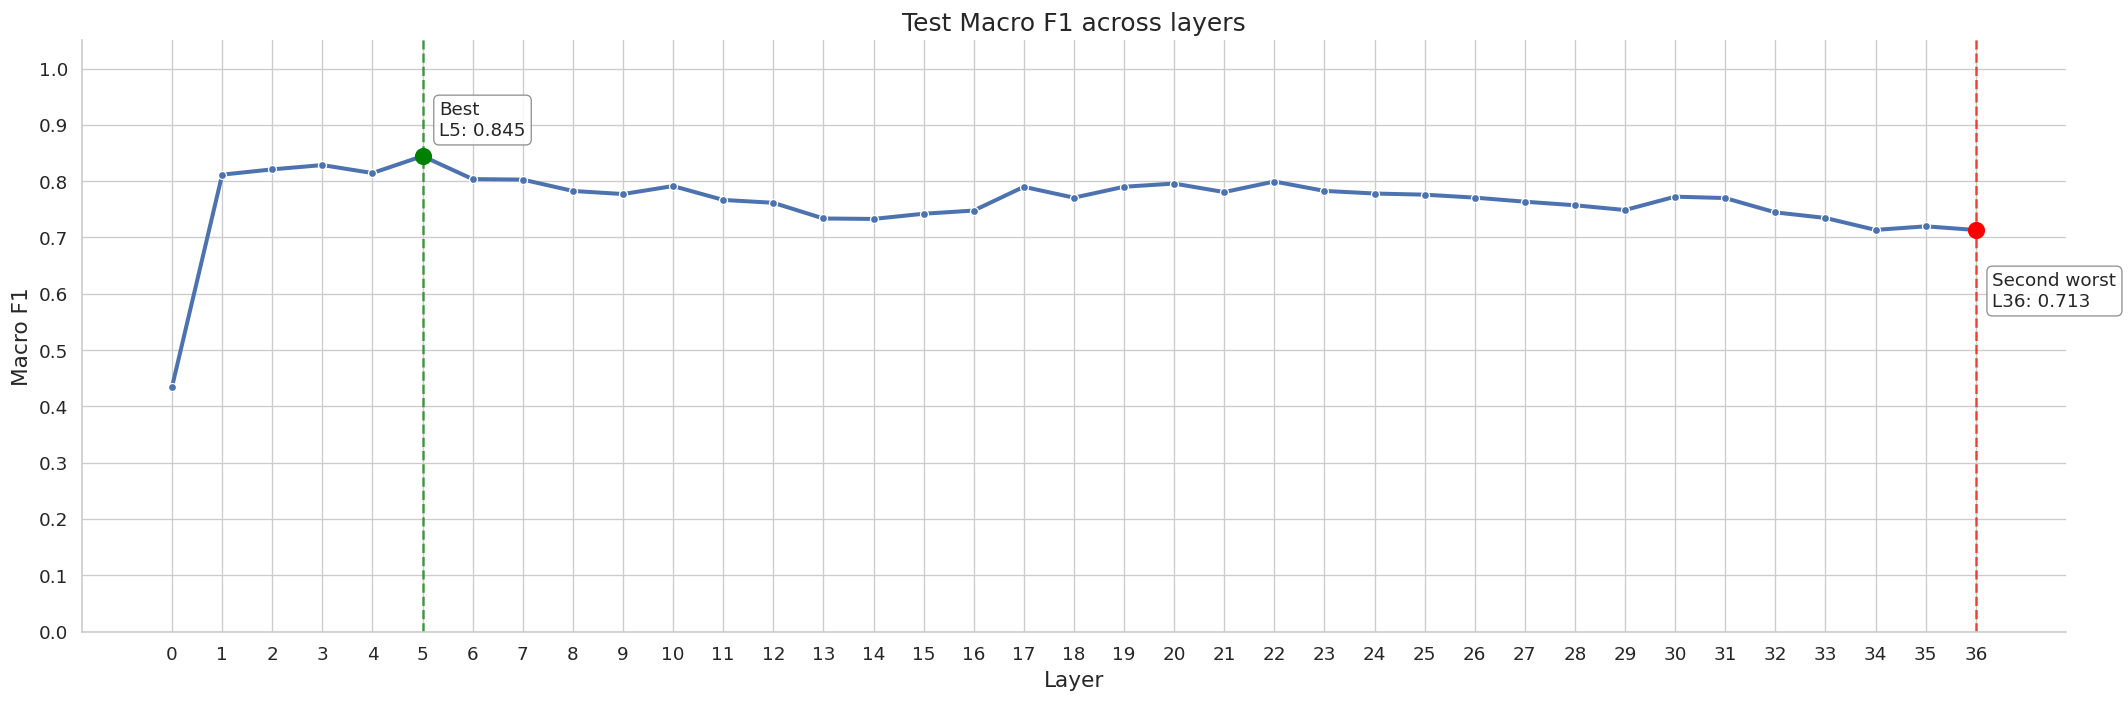

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_f1",
    save_name="test_layerwise_macro_f1_with_best_and_second_worst_value"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_train_vs_test_metrics.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_train_vs_test_metrics.pdf


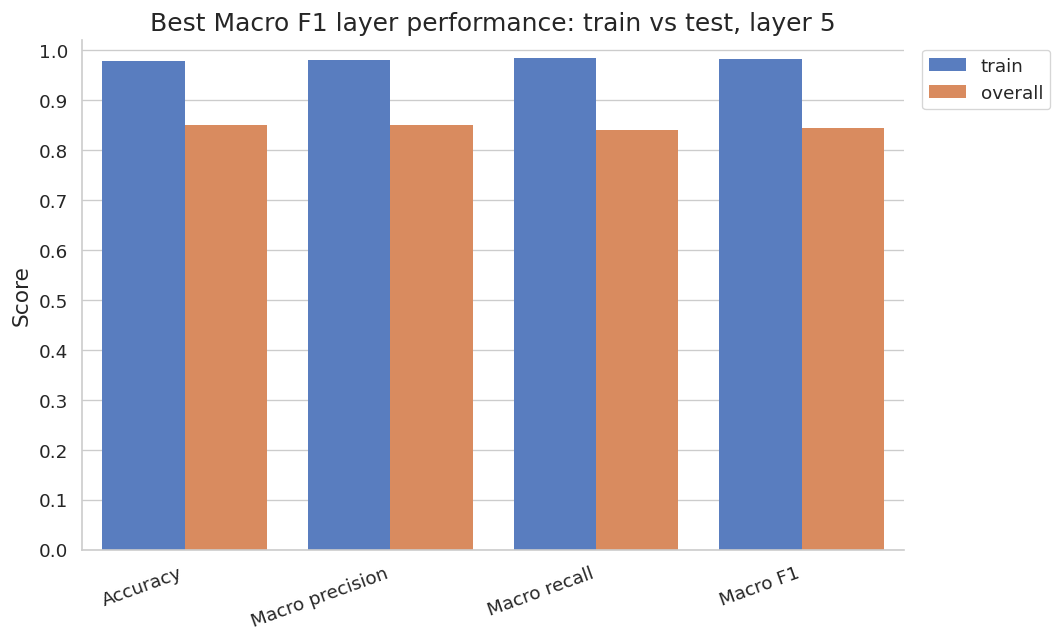

,layer,subset,metric_col,score,metric
0,5,overall,accuracy,0.851304,Accuracy
1,5,train,accuracy,0.978795,Accuracy
2,5,overall,macro_precision,0.850147,Macro precision
3,5,train,macro_precision,0.980349,Macro precision
4,5,overall,macro_recall,0.841720,Macro recall
5,5,train,macro_recall,0.984656,Macro recall
6,5,overall,macro_f1,0.844544,Macro F1
7,5,train,macro_f1,0.982360,Macro F1


In [ ]:
best_compare = df_layers[
    (df_layers["layer"] == best_layer) &
    (df_layers["subset"].isin(["train", "overall"]))
].copy()

best_compare_long = best_compare.melt(
    id_vars=["layer", "subset"],
    value_vars=["accuracy", "macro_precision", "macro_recall", "macro_f1"],
    var_name="metric_col",
    value_name="score"
)

best_compare_long["metric"] = best_compare_long["metric_col"].map(METRIC_NAME_MAP)

plt.figure(figsize=(9, 5.5))

sns.barplot(
    data=best_compare_long,
    x="metric",
    y="score",
    hue="subset",
    hue_order=["train", "overall"],
    palette="muted",
    linewidth=0
)

plt.title(f"Best {BEST_LAYER_METRIC_LABEL} layer performance: train vs test, layer {best_layer}")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.legend(
    title=None,
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_train_vs_test_metrics")
plt.show()

best_compare_long

In [ ]:
def plot_train_test_metric_with_best(metric_col, save_name):
    metric_label = verify_metric_column(
        df_train_test,
        metric_col,
        id_cols=["layer", "split"]
    )

    plt.figure(figsize=(18, 6))

    sns.lineplot(
        data=df_train_test,
        x="layer",
        y=metric_col,
        hue="split",
        marker="o",
        linewidth=2.4,
        palette="muted"
    )

    best_rows = {}

    for split_name in ["train", "test"]:
        split_df = df_train_test[df_train_test["split"] == split_name].copy()

        if split_df.empty:
            raise ValueError(f"No rows found for split='{split_name}'.")

        best_row = split_df.loc[split_df[metric_col].idxmax()]

        best_layer_for_split = int(best_row["layer"])
        best_score = best_row[metric_col]

        expected_best_score = split_df[metric_col].max()

        assert np.isclose(best_score, expected_best_score), (
            f"Best score mismatch for split={split_name}, metric={metric_col}: "
            f"got {best_score}, expected {expected_best_score}"
        )

        best_rows[split_name] = {
            "layer": best_layer_for_split,
            "score": best_score
        }

    for split_name, offset_y in zip(["train", "test"], [-10, -38]):
        best_layer_for_split = best_rows[split_name]["layer"]
        best_score = best_rows[split_name]["score"]

        plt.axvline(
            best_layer_for_split,
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            color="green",
            label=f"Best {split_name}: L{best_layer_for_split} = {best_score:.3f}"
        )

        plt.scatter(
            best_layer_for_split,
            best_score,
            s=90,
            color="green",
            zorder=5,
        )

        plt.annotate(
            f"Best {split_name}\nL{best_layer_for_split}: {best_score:.3f}",
            xy=(best_layer_for_split, best_score),
            xytext=(10, offset_y),
            textcoords="offset points",
            fontsize=11,
            ha="left",
            va="bottom" if offset_y > 0 else "top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="white",
                ec="green",
                alpha=0.9
            ),
        )

    plt.title(make_metric_title(
        prefix="Train vs Test",
        metric_col=metric_col,
        suffix="across layers",
        df=df_train_test
    ))

    plt.xlabel("Layer")
    plt.ylabel(metric_label)
    plt.ylim(0, 1.05)
    plt.yticks(np.arange(0, 1.01, 0.1))
    plt.xticks(sorted(df_train_test["layer"].unique()))
    plt.legend(title=None, frameon=True)
    plt.tight_layout()

    save_fig(save_name)
    plt.show()

Verified metric column: accuracy
Display label: Accuracy
   layer split  accuracy
0      0  test  0.484848
1      1  test  0.832276
2      2  test  0.844726
3      3  test  0.848250
4      4  test  0.837914
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_accuracy_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_accuracy_with_best.pdf


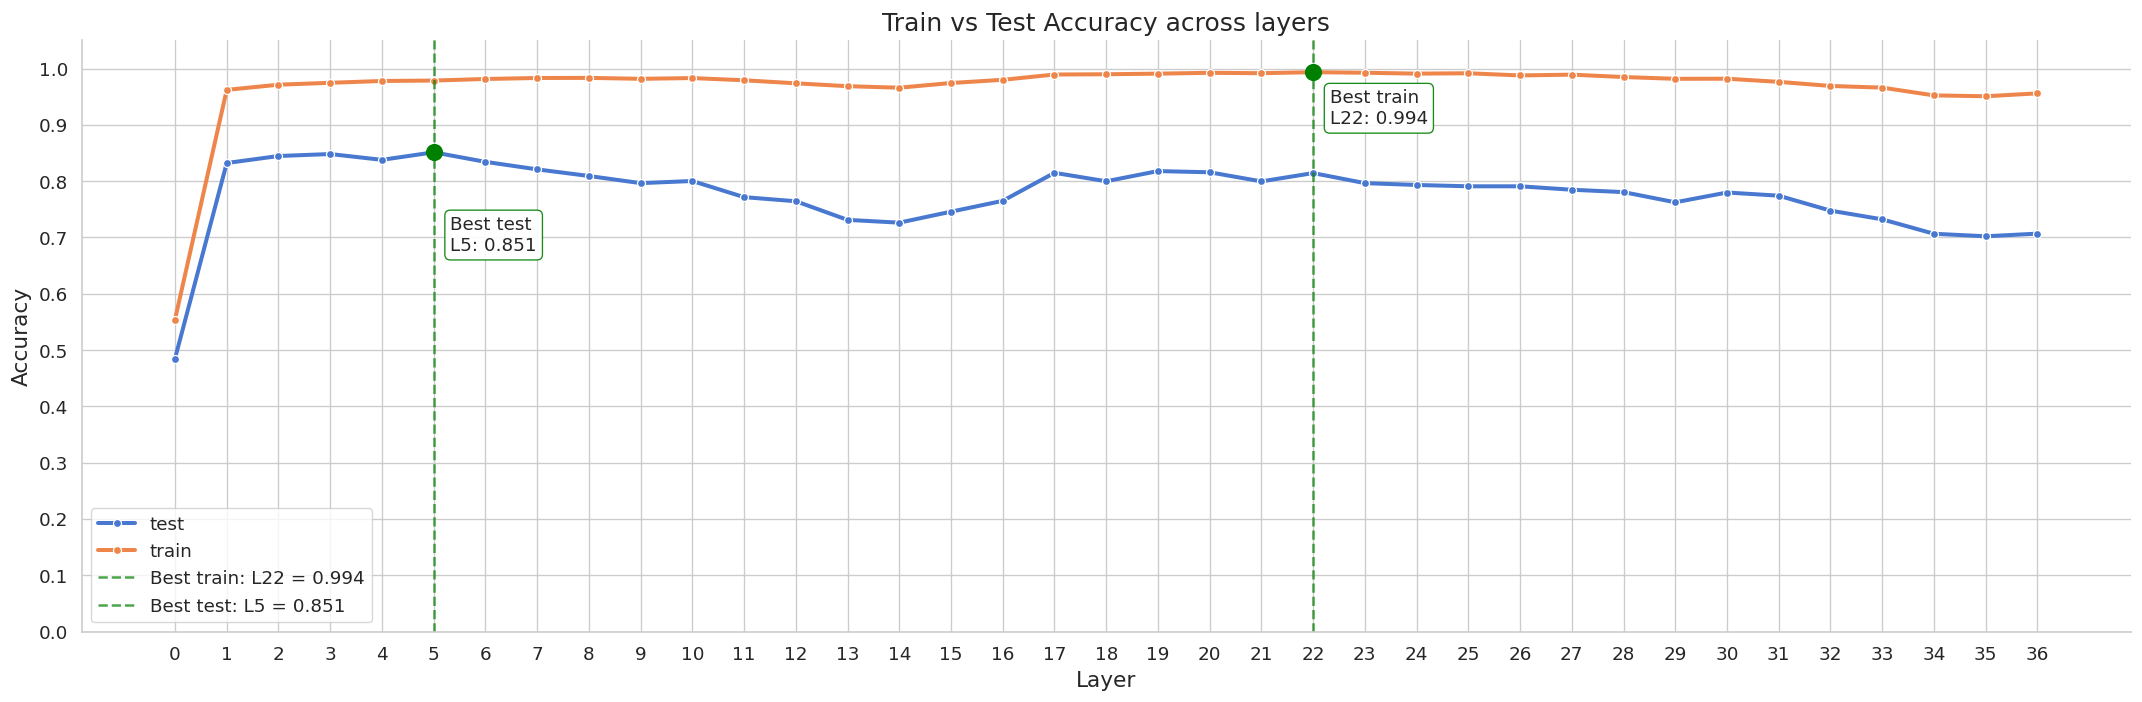

In [ ]:
plot_train_test_metric_with_best(
    metric_col="accuracy",
    save_name="layerwise_train_vs_test_accuracy_with_best"
)

Verified metric column: macro_precision
Display label: Macro precision
   layer split  macro_precision
0      0  test         0.397431
1      1  test         0.808553
2      2  test         0.812701
3      3  test         0.824170
4      4  test         0.810127
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_precision_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_precision_with_best.pdf


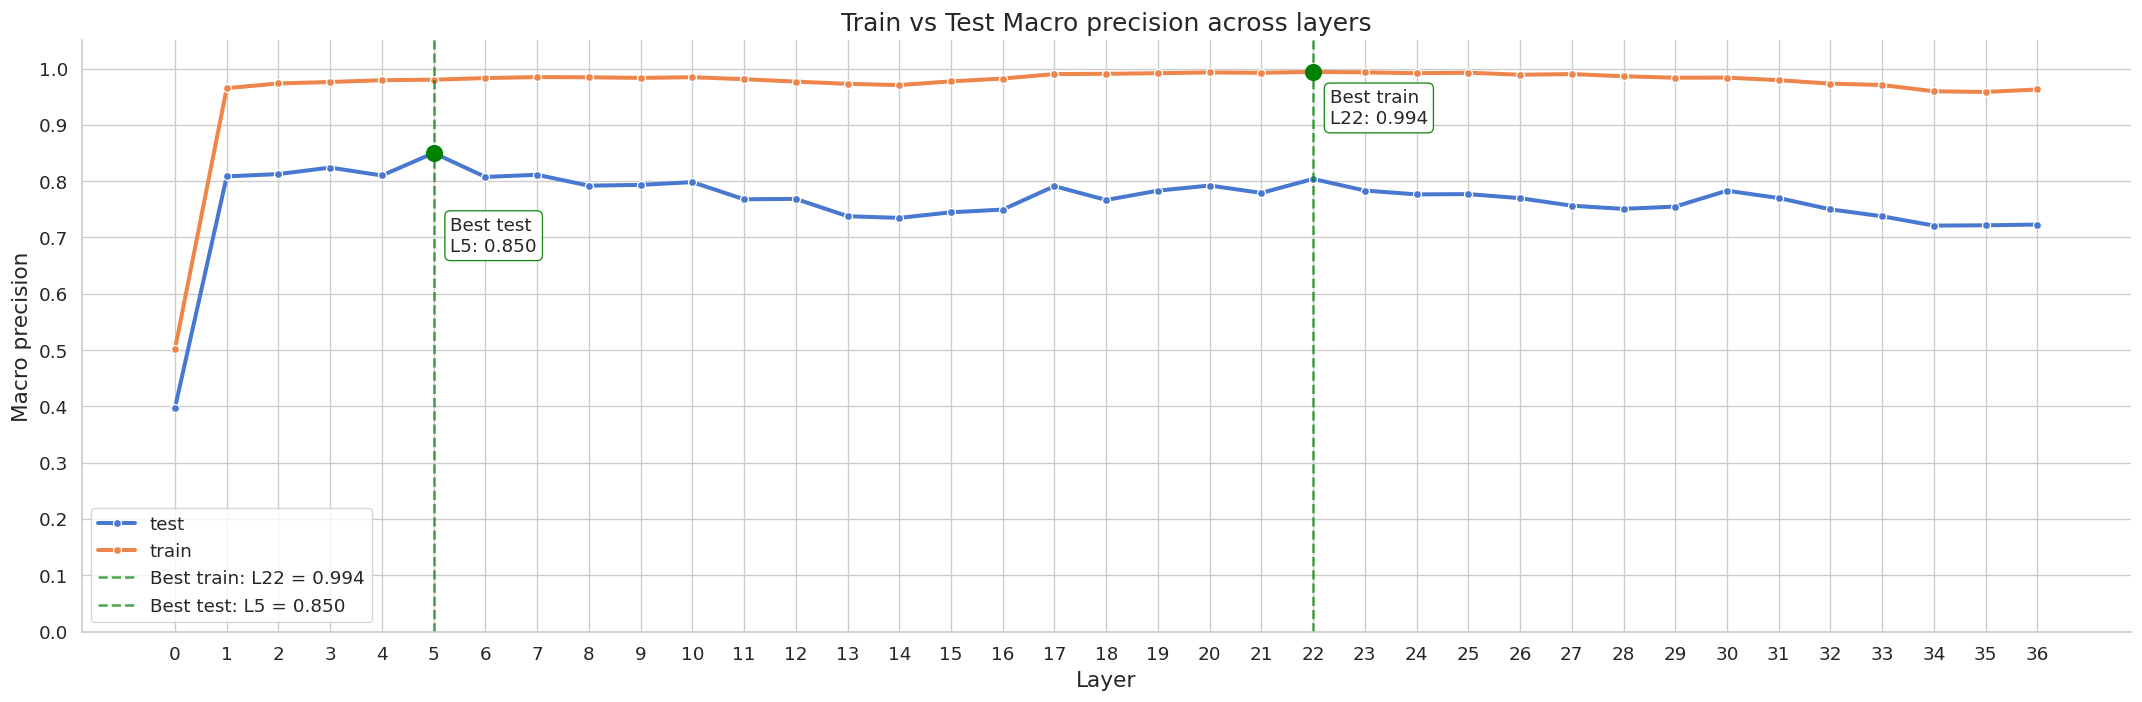

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_precision",
    save_name="layerwise_train_vs_test_macro_precision_with_best"
)

Verified metric column: macro_recall
Display label: Macro recall
   layer split  macro_recall
0      0  test      0.550492
1      1  test      0.818152
2      2  test      0.836339
3      3  test      0.837367
4      4  test      0.822442
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_recall_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_recall_with_best.pdf


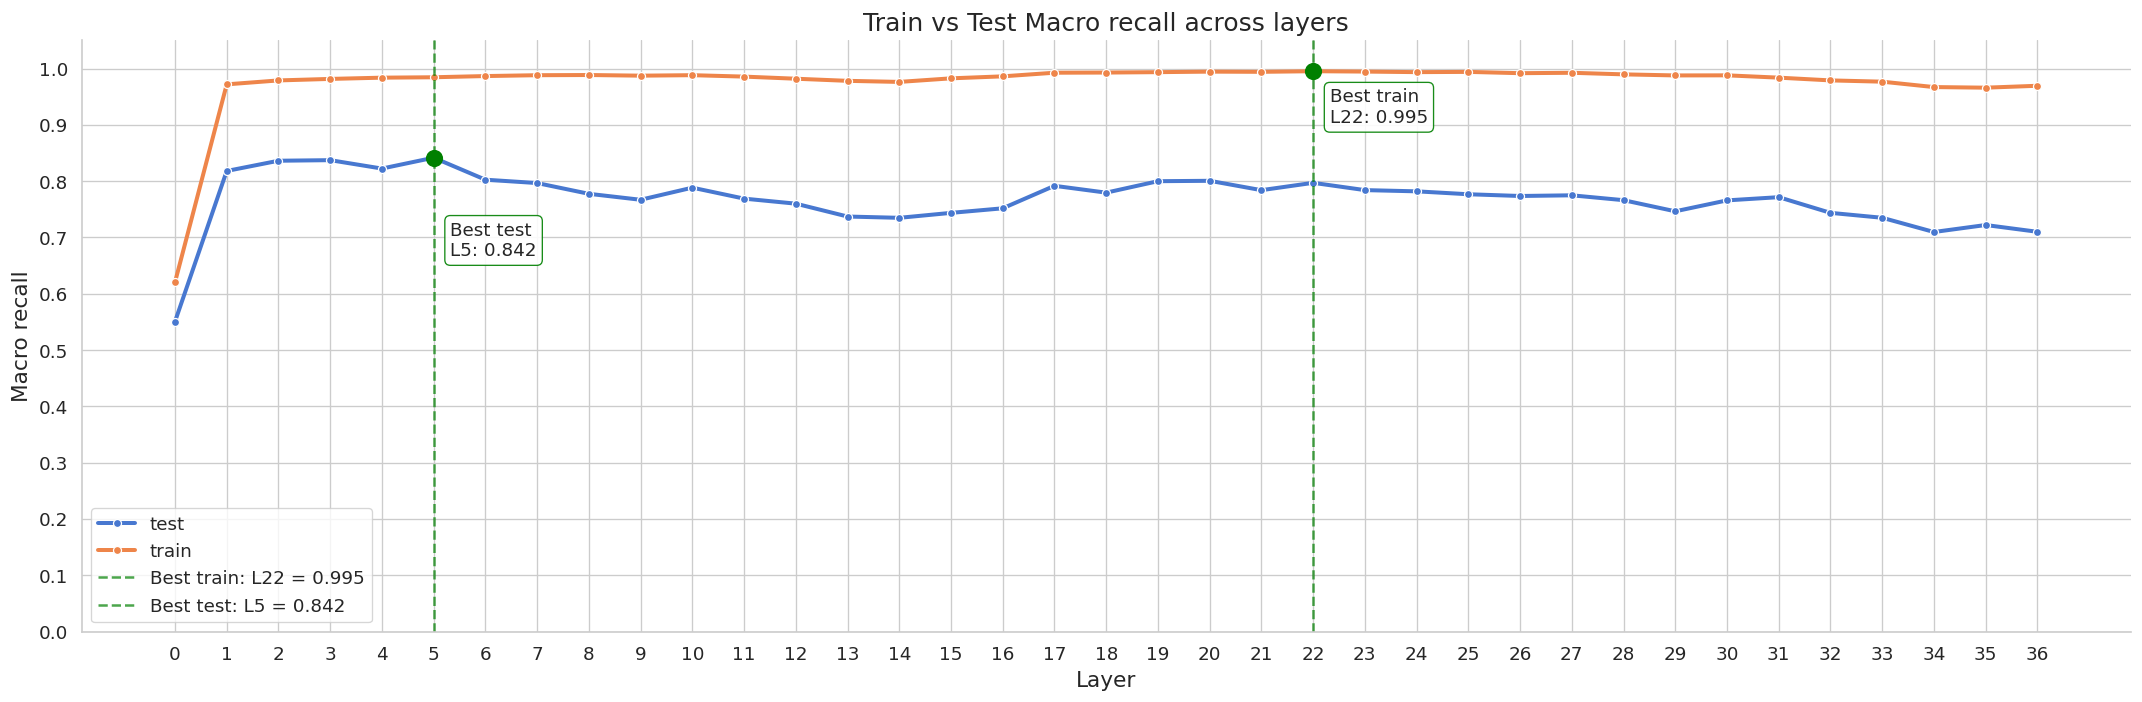

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_recall",
    save_name="layerwise_train_vs_test_macro_recall_with_best"
)

Verified metric column: macro_f1
Display label: Macro F1
   layer split  macro_f1
0      0  test  0.434862
1      1  test  0.811616
2      2  test  0.821016
3      3  test  0.828642
4      4  test  0.814498
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_f1_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_macro_f1_with_best.pdf


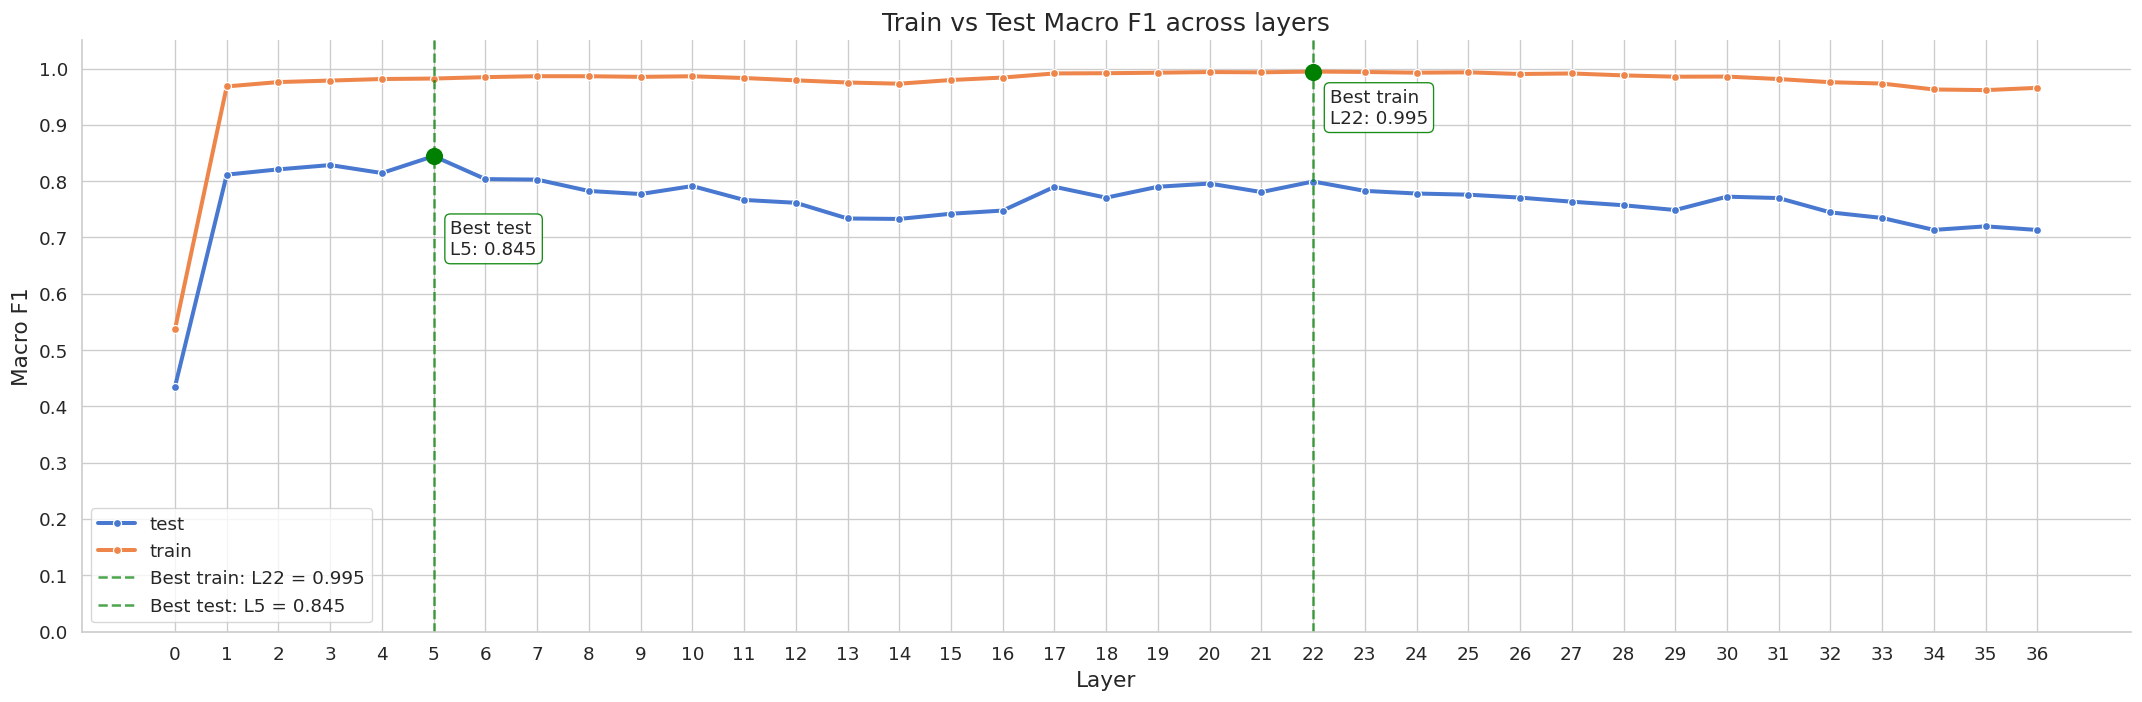

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_f1",
    save_name="layerwise_train_vs_test_macro_f1_with_best"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_all_metrics.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/layerwise_train_vs_test_all_metrics.pdf


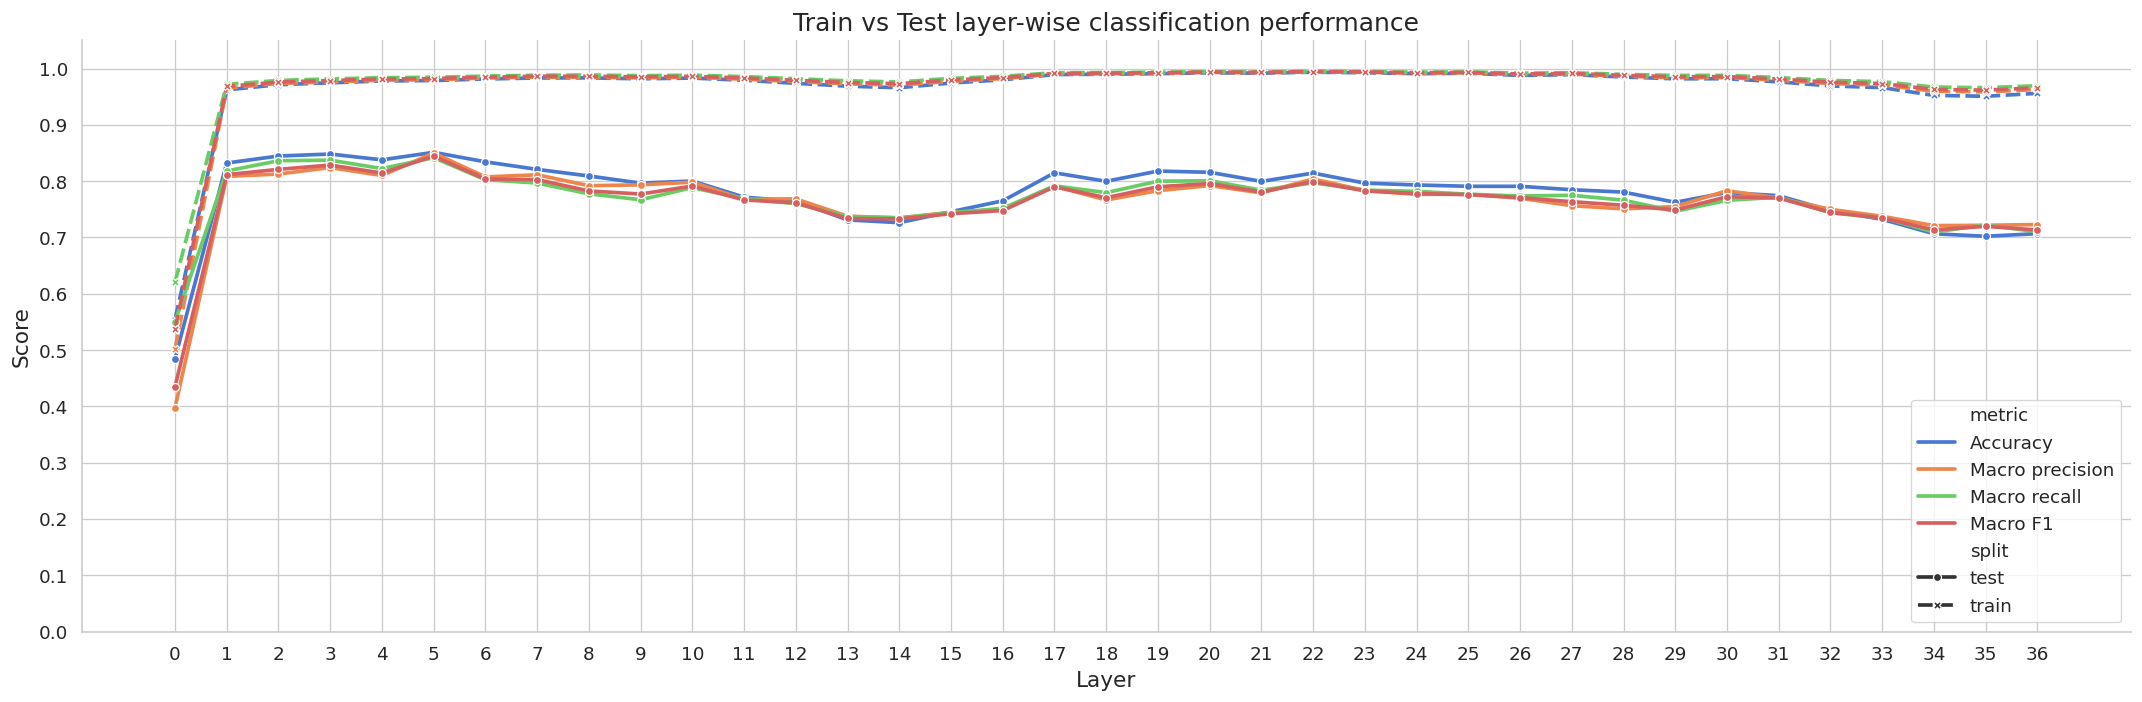

In [ ]:
df_train_test_long = df_train_test.melt(
    id_vars=["layer", "split"],
    value_vars=["accuracy", "macro_precision", "macro_recall", "macro_f1"],
    var_name="metric_col",
    value_name="score"
)

df_train_test_long["metric"] = df_train_test_long["metric_col"].map(METRIC_NAME_MAP)

plt.figure(figsize=(18, 6))

sns.lineplot(
    data=df_train_test_long,
    x="layer",
    y="score",
    hue="metric",
    style="split",
    markers=True,
    dashes=True,
    linewidth=2.2,
    palette="muted"
)

plt.title("Train vs Test layer-wise classification performance")
plt.xlabel("Layer")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(sorted(df_train_test_long["layer"].unique()))
plt.legend(title=None, frameon=True, loc="lower right")
plt.tight_layout()

save_fig("layerwise_train_vs_test_all_metrics")
plt.show()

In [ ]:
per_label_rows = []

for layer_result in results["results_by_layer"]:
    layer = int(layer_result["layer"])

    if "overall" not in layer_result:
        continue

    report = layer_result["overall"].get("classification_report", {})

    for label in label_order:
        label_report = report.get(label, {})

        per_label_rows.append({
            "layer": layer,
            "label": label,
            "precision": label_report.get("precision", np.nan),
            "recall": label_report.get("recall", np.nan),
            "f1_score": label_report.get("f1-score", np.nan),
            "support": label_report.get("support", np.nan),
        })

df_label_metrics = pd.DataFrame(per_label_rows)

print(df_label_metrics.head())
print("\nShape:", df_label_metrics.shape)

   layer     label  precision    recall  f1_score  support
0      0     above   0.370567  0.541451  0.440000    386.0
1      0     below   0.338843  0.510903  0.407453    321.0
2      0  contains   0.181818  0.769231  0.294118     26.0
3      0        in   0.297872  0.736842  0.424242     57.0
4      0   left_of   0.354610  0.211640  0.265076    945.0

Shape: (333, 6)


In [ ]:
LABEL_METRIC_NAME_MAP = {
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1 score",
    "support": "Support",
}


def require_label_metric_column(df, metric_col):
    if metric_col not in df.columns:
        raise ValueError(
            f"Label metric column '{metric_col}' does not exist. "
            f"Available columns: {list(df.columns)}"
        )

    if metric_col not in LABEL_METRIC_NAME_MAP:
        raise ValueError(
            f"Label metric column '{metric_col}' is not registered in LABEL_METRIC_NAME_MAP."
        )

    if not pd.api.types.is_numeric_dtype(df[metric_col]):
        raise TypeError(f"Label metric column '{metric_col}' is not numeric.")

    return LABEL_METRIC_NAME_MAP[metric_col]

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_per_label_precision_recall_f1.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_per_label_precision_recall_f1.pdf


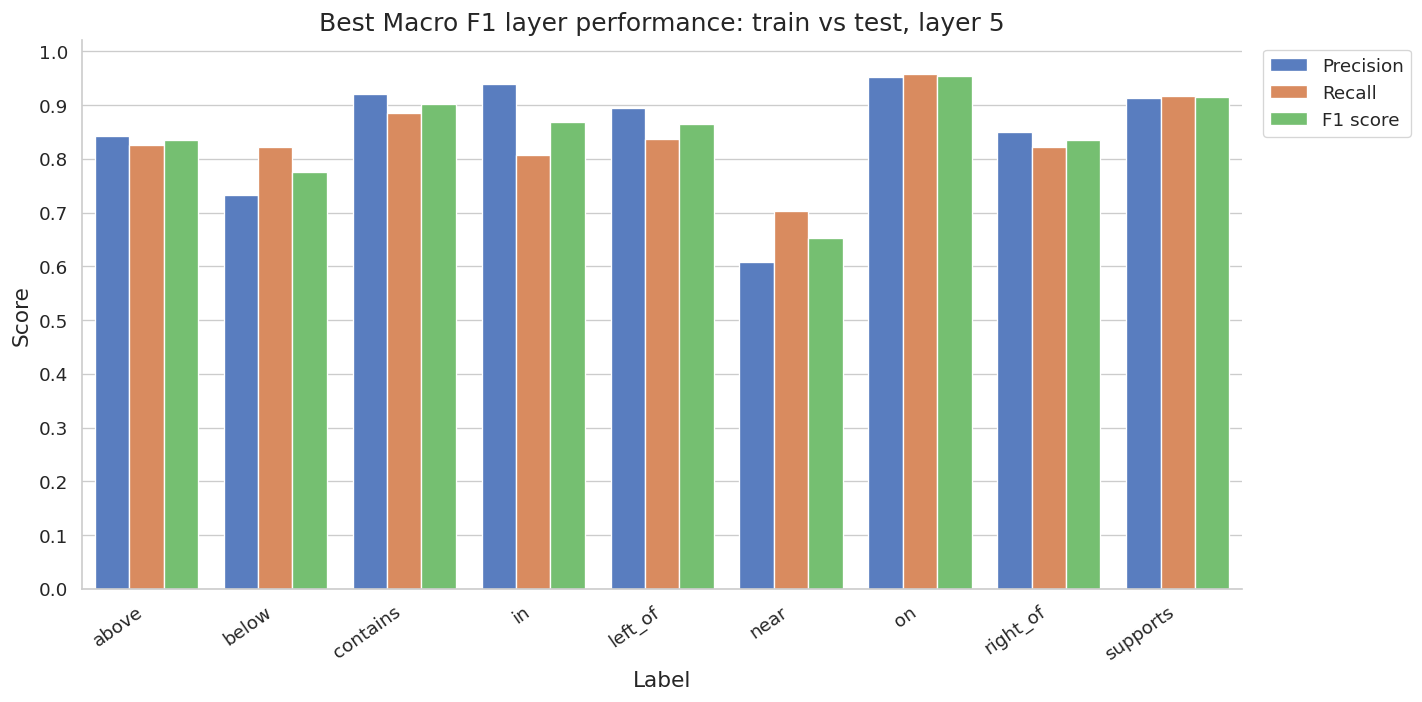

In [ ]:
best_label_df = df_label_metrics[df_label_metrics["layer"] == best_layer].copy()

best_label_long = best_label_df.melt(
    id_vars=["layer", "label", "support"],
    value_vars=["precision", "recall", "f1_score"],
    var_name="metric_col",
    value_name="score"
)

best_label_long["metric"] = best_label_long["metric_col"].map(LABEL_METRIC_NAME_MAP)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_label_long,
    x="label",
    y="score",
    hue="metric",
    palette="muted"
)

plt.title(f"Best {BEST_LAYER_METRIC_LABEL} layer performance: train vs test, layer {best_layer}")
plt.xlabel("Label")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(rotation=35, ha="right")
plt.legend(
    title=None,
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_overall_per_label_precision_recall_f1")
plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_per_label_recall.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_per_label_recall.pdf


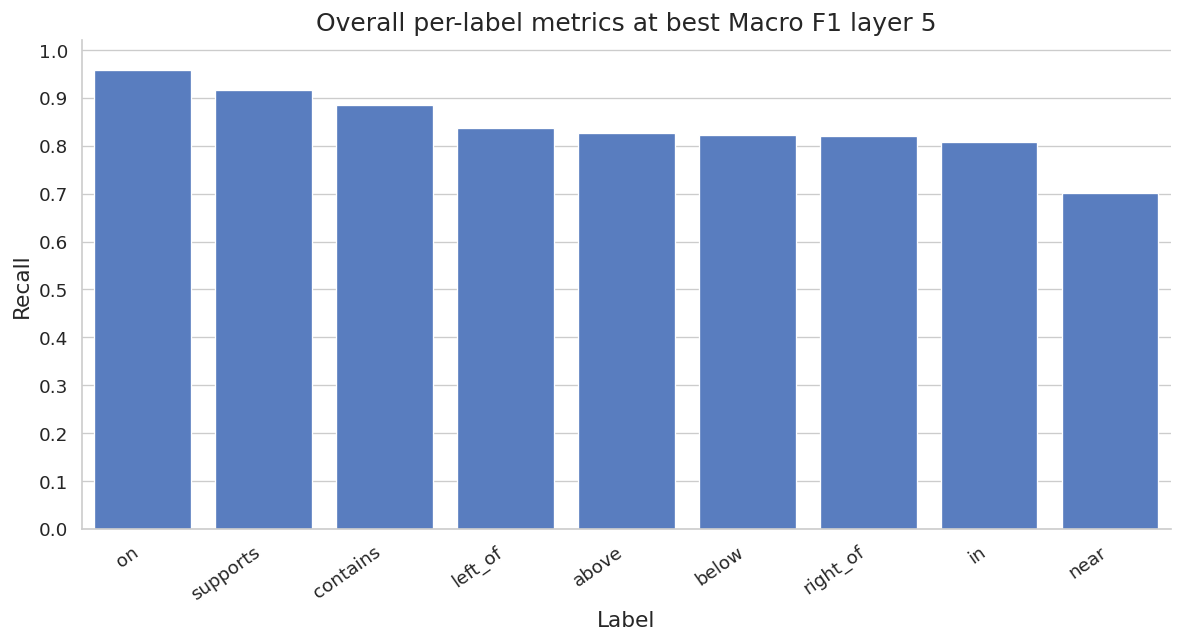

In [ ]:
label_metric_col = "recall"
label_metric_label = require_label_metric_column(df_label_metrics, label_metric_col)

best_label_df = df_label_metrics[df_label_metrics["layer"] == best_layer].copy()

plt.figure(figsize=(10, 5.5))

order_by_metric = best_label_df.sort_values(label_metric_col, ascending=False)["label"]

sns.barplot(
    data=best_label_df,
    x="label",
    y=label_metric_col,
    order=order_by_metric,
    #alpha=0.95,
    color=sns.color_palette("muted")[0]
)

plt.title(f"Overall per-label metrics at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Label")
plt.ylabel(label_metric_label)
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_overall_per_label_{label_metric_col}")
plt.show()

In [ ]:
def plot_label_by_layer_heatmap(metric_col, save_name):
    metric_label = require_label_metric_column(df_label_metrics, metric_col)

    metric_matrix = df_label_metrics.pivot(
        index="label",
        columns="layer",
        values=metric_col
    ).loc[label_order]

    plt.figure(figsize=(50, 15))

    ax = sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0,
        linecolor=None,
        cbar_kws={"label": metric_label},
        annot_kws={"size": 22}
    )

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=22)
    cbar.set_label(metric_label, fontsize=22)

    plt.xlabel("Layer", fontsize=24)
    plt.ylabel("Label", fontsize=24)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.title(
        f"Overall {metric_label} heatmap by label and layer",
        fontsize=34
    )

    plt.tight_layout()

    save_fig(save_name)
    plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_recall_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_recall_heatmap.pdf


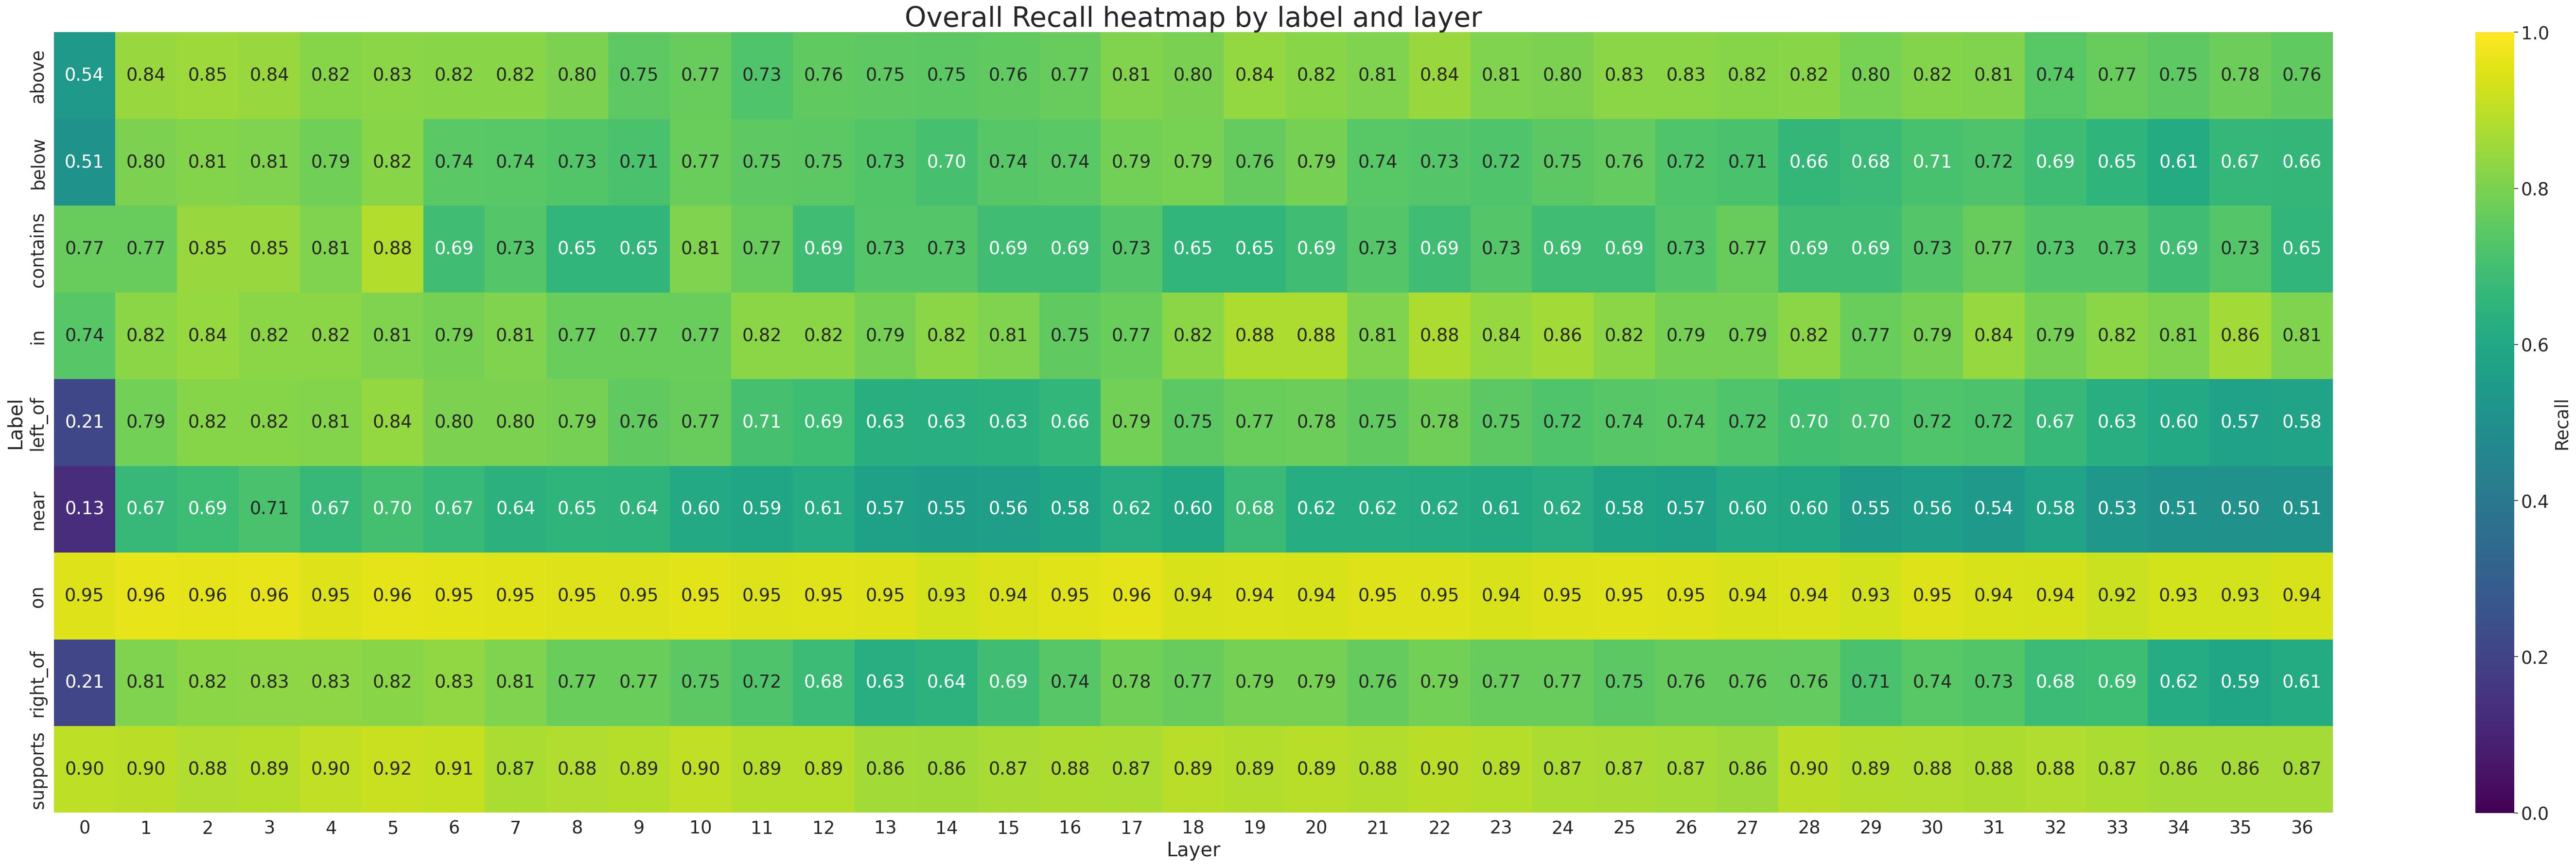

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="recall",
    save_name="overall_label_by_layer_recall_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_precision_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_precision_heatmap.pdf


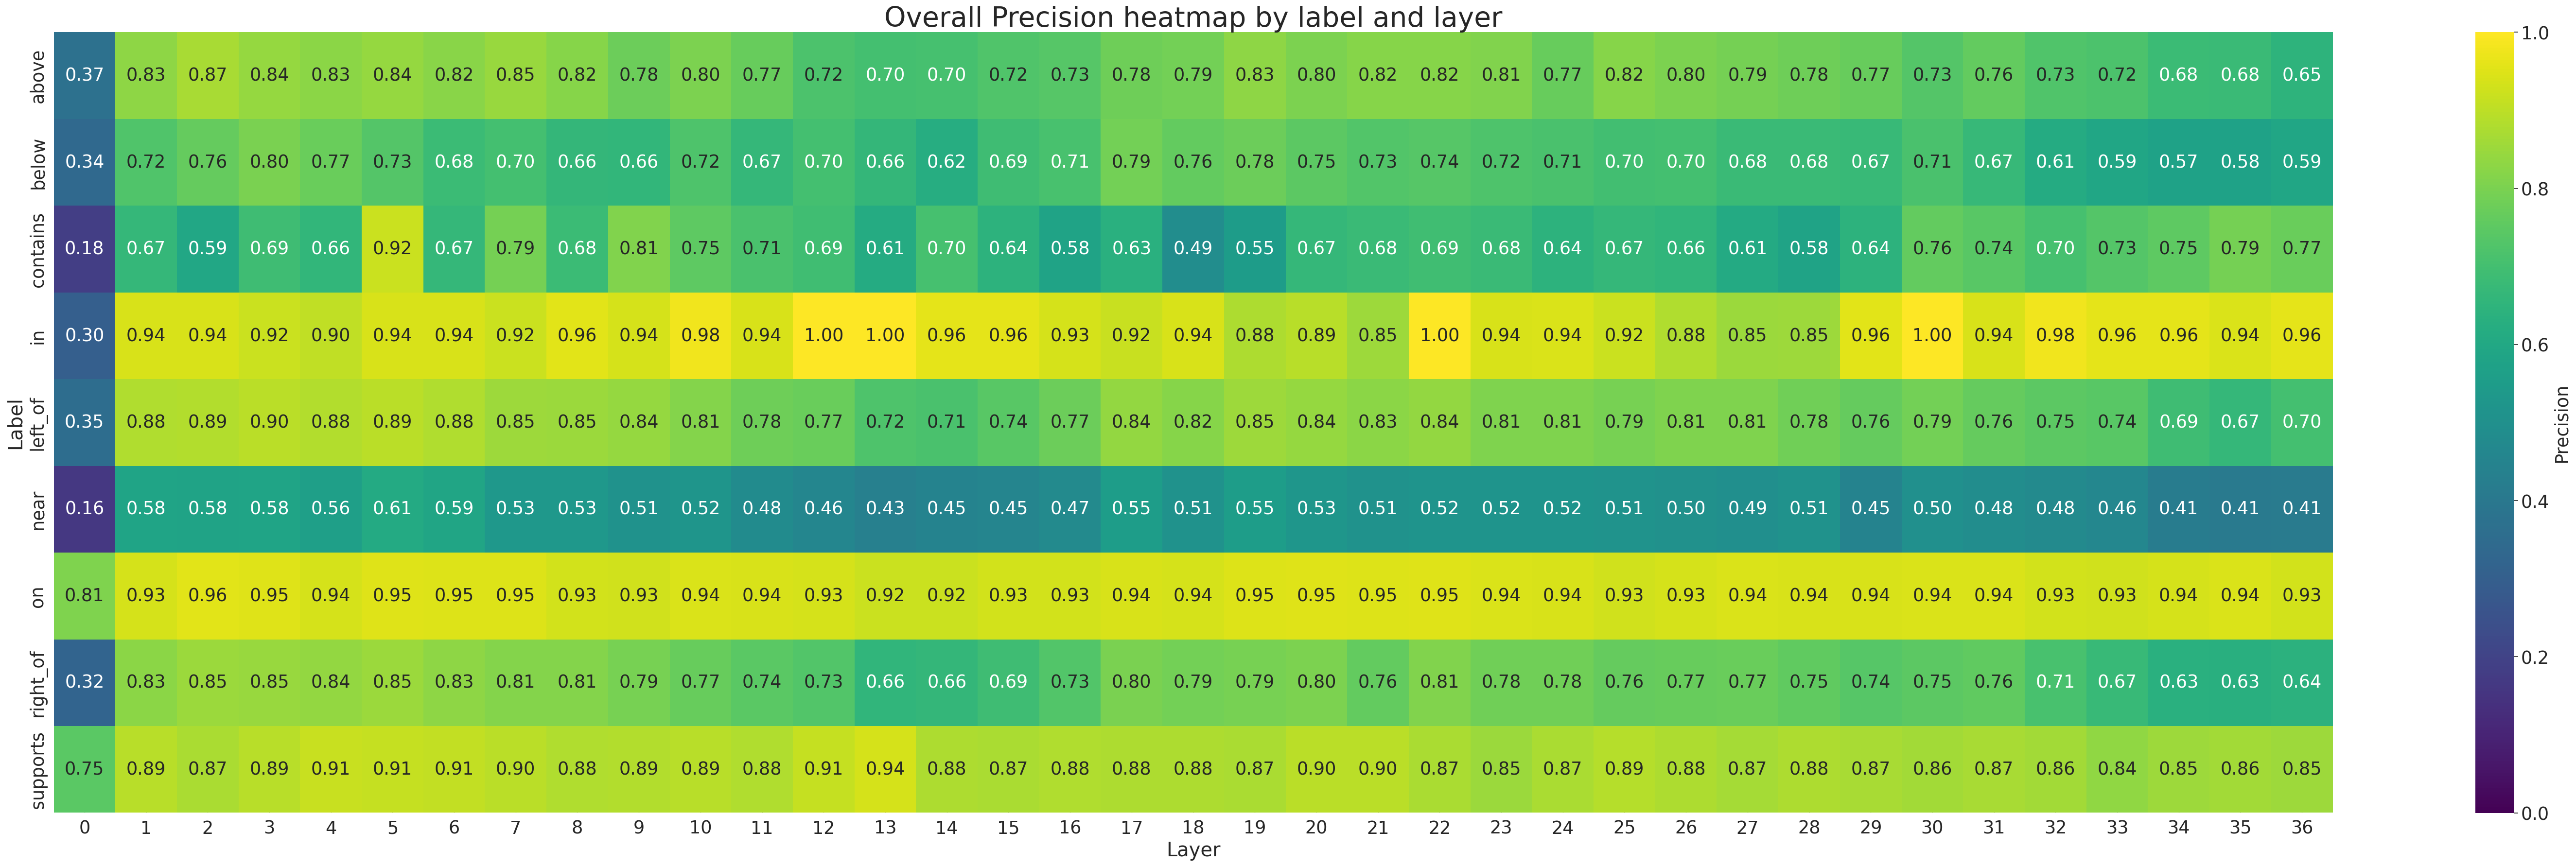

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="precision",
    save_name="overall_label_by_layer_precision_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_f1_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/overall_label_by_layer_f1_heatmap.pdf


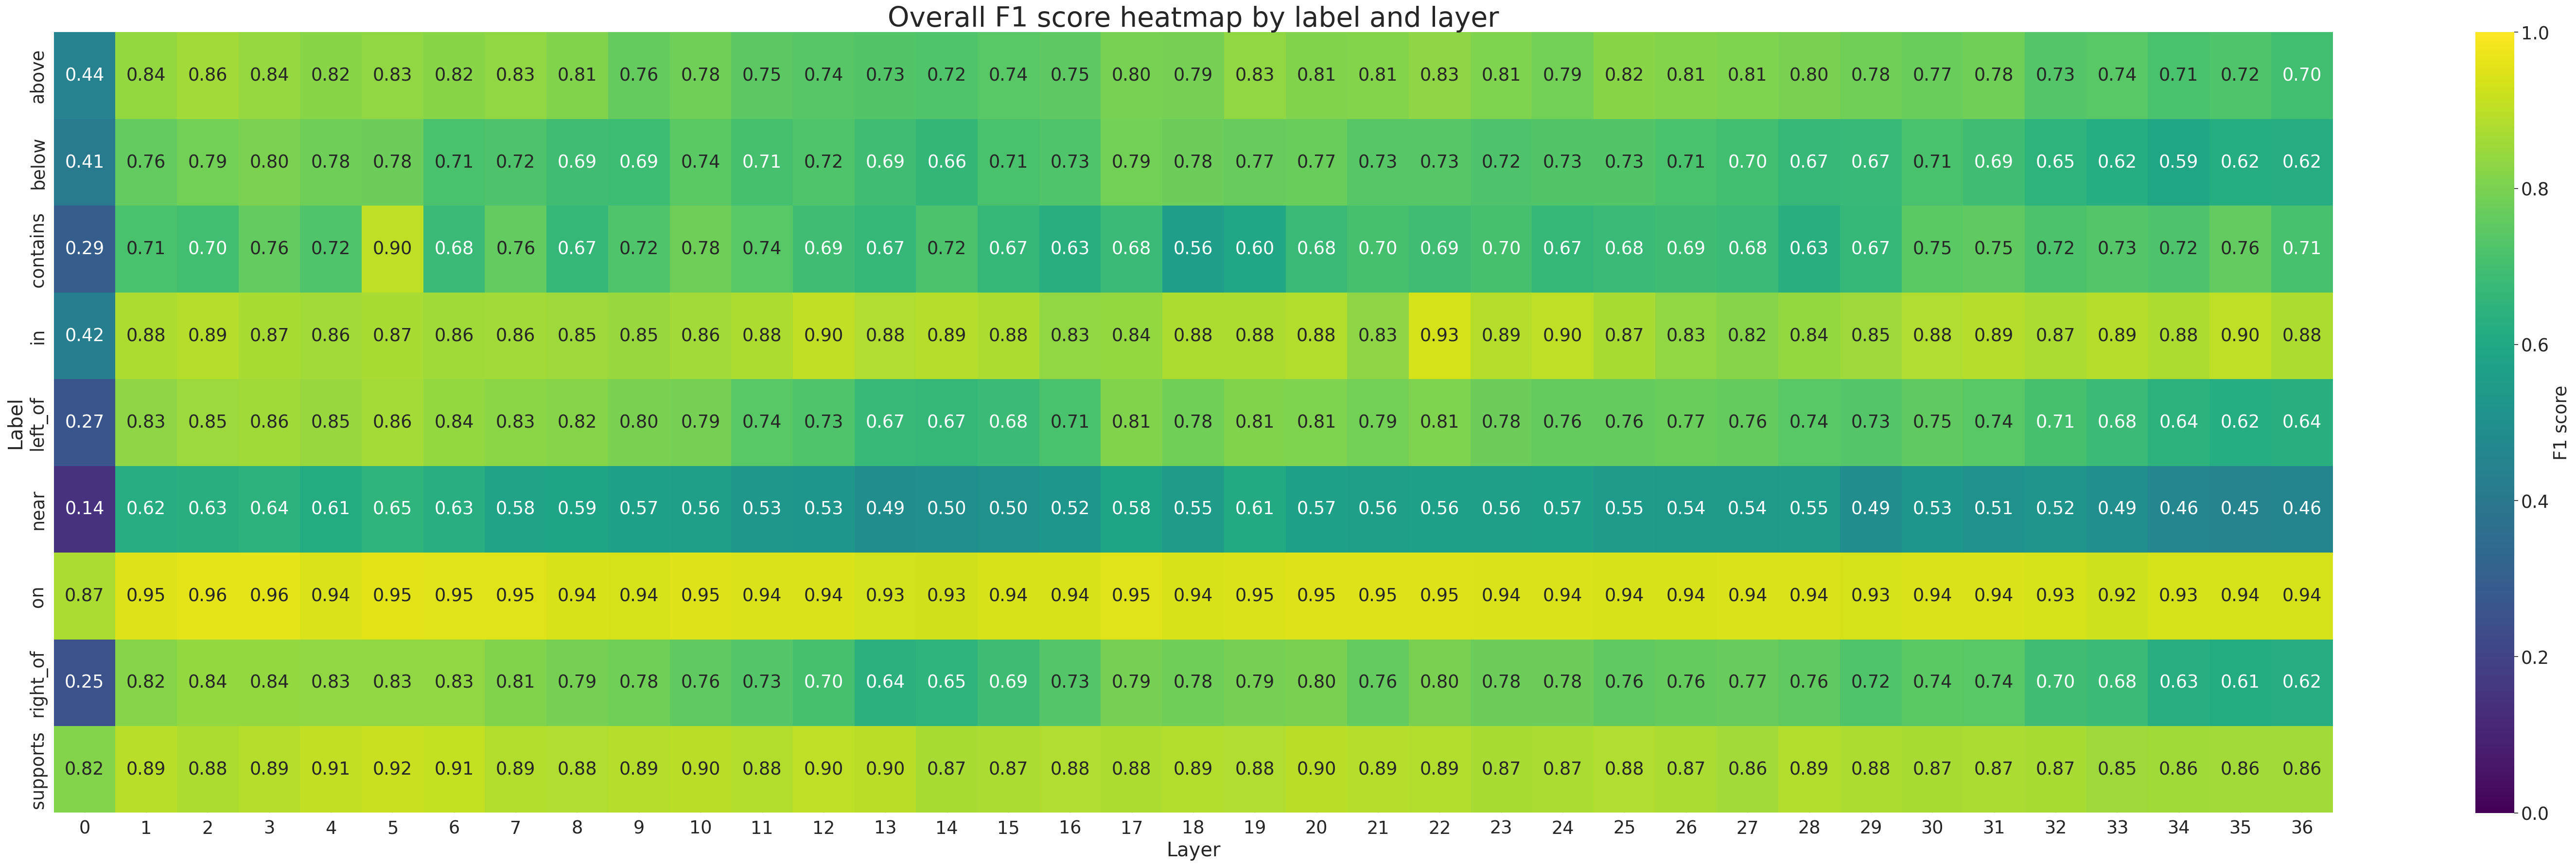

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="f1_score",
    save_name="overall_label_by_layer_f1_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_confusion_matrix.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_confusion_matrix.pdf


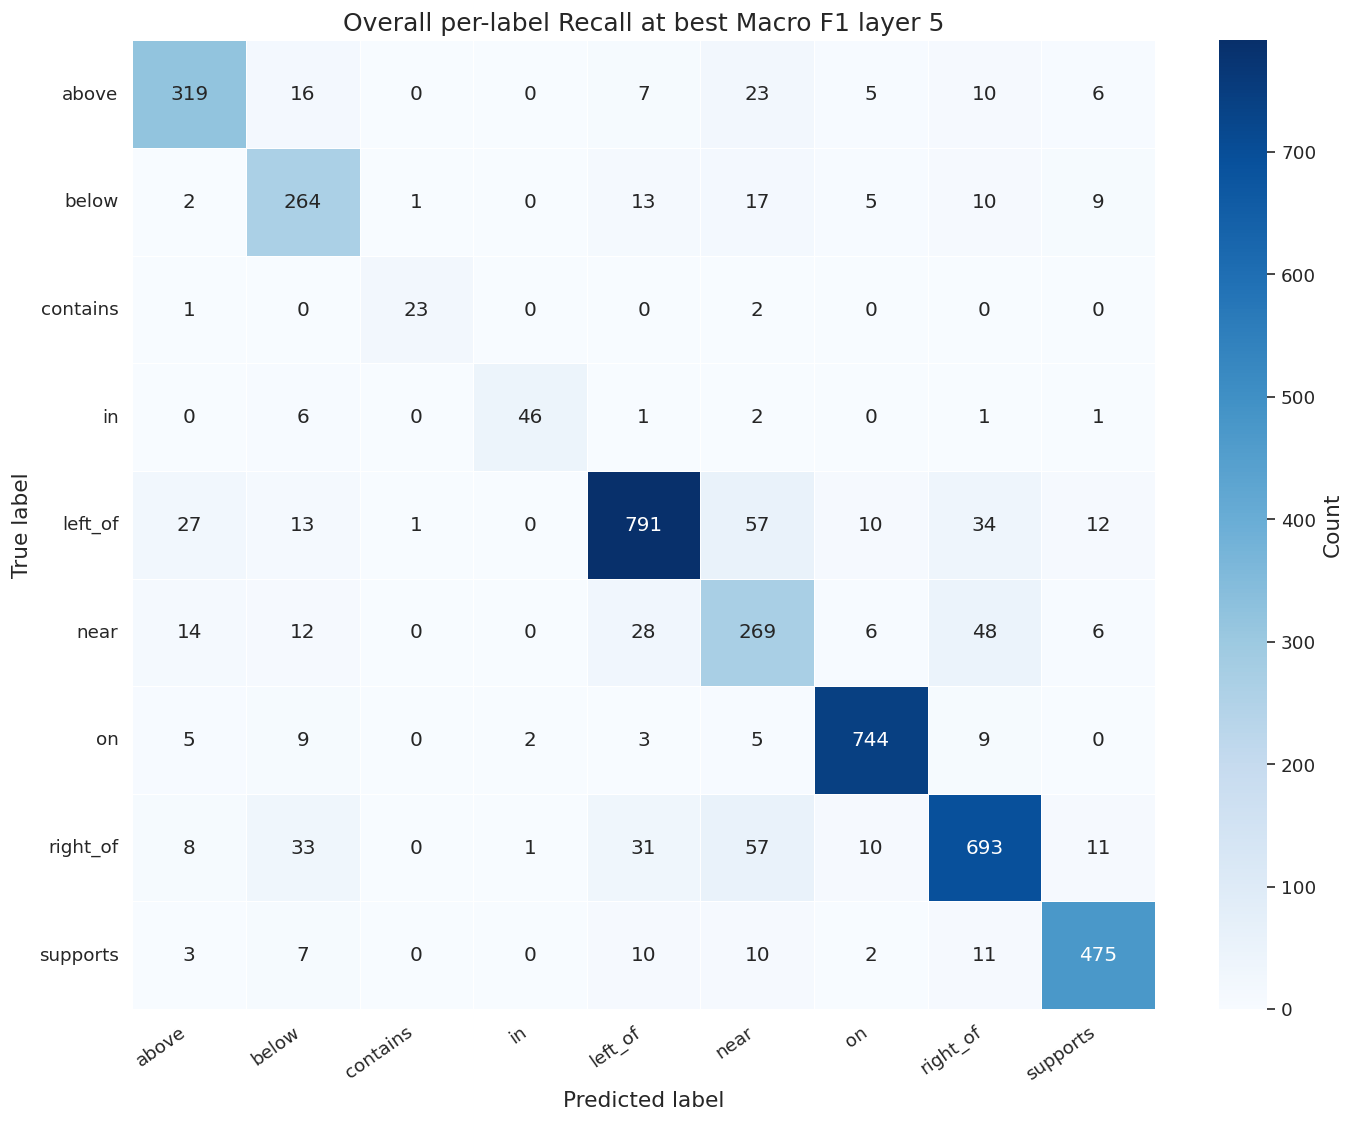

In [ ]:
best_layer_result = None

for layer_result in results["results_by_layer"]:
    if int(layer_result["layer"]) == best_layer:
        best_layer_result = layer_result
        break

assert best_layer_result is not None, f"Best layer {best_layer} not found."

cm = np.asarray(best_layer_result["overall"]["confusion_matrix"])

plt.figure(figsize=(12, 9.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
    linewidths=0.4,
    cbar_kws={"label": "Count"},
    annot_kws={"size": 12}
)

plt.title(f"Overall per-label {label_metric_label} at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_overall_confusion_matrix")
plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_normalized_confusion_matrix.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b/best_macro_f1_layer_5_overall_normalized_confusion_matrix.pdf


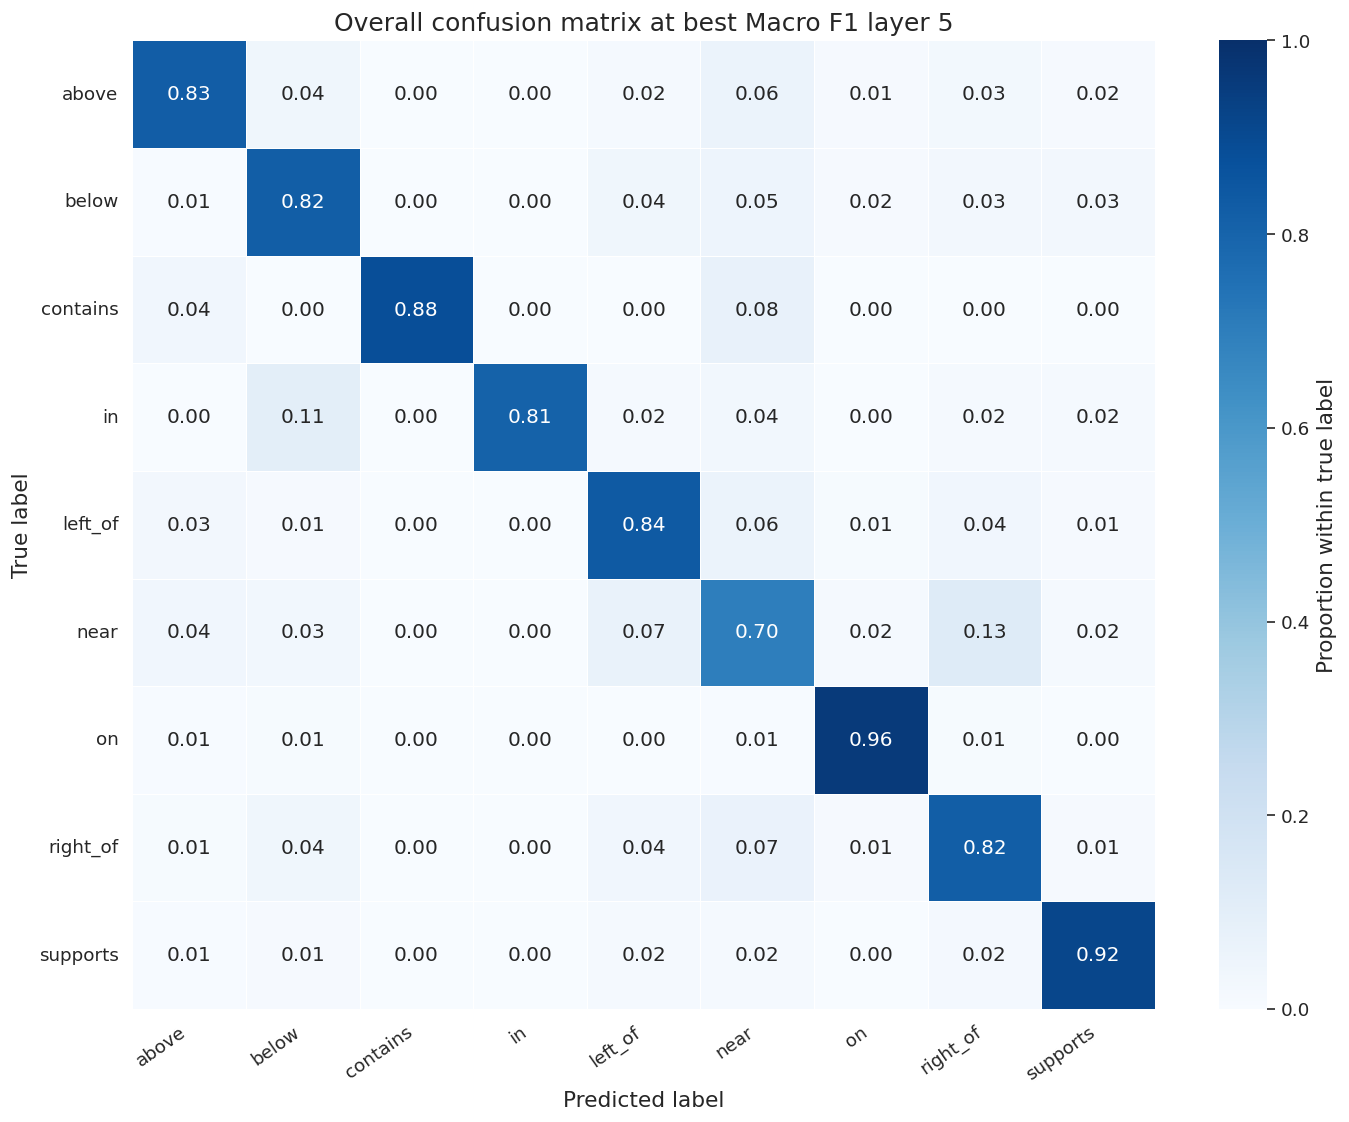

In [ ]:
cm = np.asarray(best_layer_result["overall"]["confusion_matrix"], dtype=float)

row_sums = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

plt.figure(figsize=(12, 9.5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
    linewidths=0.4,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion within true label"},
    annot_kws={"size": 12},
)

plt.title(f"Overall confusion matrix at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_overall_normalized_confusion_matrix")
plt.show()

In [ ]:
files = sorted(OUT_DIR.glob("*"))

print("OUT_DIR:", OUT_DIR)
print("Number of files:", len(files))

for p in files:
    print(p.name)

OUT_DIR: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_ex_q253b
Number of files: 36
best_macro_f1_layer_5_overall_confusion_matrix.pdf
best_macro_f1_layer_5_overall_confusion_matrix.png
best_macro_f1_layer_5_overall_normalized_confusion_matrix.pdf
best_macro_f1_layer_5_overall_normalized_confusion_matrix.png
best_macro_f1_layer_5_overall_per_label_precision_recall_f1.pdf
best_macro_f1_layer_5_overall_per_label_precision_recall_f1.png
best_macro_f1_layer_5_overall_per_label_recall.pdf
best_macro_f1_layer_5_overall_per_label_recall.png
best_macro_f1_layer_5_train_vs_test_metrics.pdf
best_macro_f1_layer_5_train_vs_test_metrics.png
layerwise_train_vs_test_accuracy_with_best.pdf
layerwise_train_vs_test_accuracy_with_best.png
layerwise_train_vs_test_all_metrics.pdf
layerwise_train_vs_test_all_metrics.png
layerwise_train_vs_test_macro_f1_with_best.pdf
layerwise_train_vs_test_macro_f1_with_best.png
layerwise_train_vs_test_macro_precision_wit